# 层次聚类（基于BerTopic）

In [1]:
import os
import json
import math
import time
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import normalize

from collections import defaultdict

from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.pairwise import cosine_similarity

from umap import UMAP

from scipy.sparse import csr_matrix
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

## 数据准备

In [10]:
# =========================
# 2.1 配置
# =========================
DATA_PATH = "./data/dataCleanSCIE.csv"   # 改成你的路径
OUTPUT_DIR = "outputs_manual_topic_model"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SEED = 42
np.random.seed(SEED)

# =========================
# 2.2 读取数据
# =========================
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Raw rows: {len(df_raw):,}, columns: {df_raw.shape[1]}")

# =========================
# 2.3 列名映射
# =========================
COL_MAP = {
    "TI": "title",
    "AB": "abstract",
    "PY": "year",
    "TC": "citation",
    "UT": "paper_id",
    "country": "country",
}

cols_present = {k: v for k, v in COL_MAP.items() if k in df_raw.columns}
df = df_raw.rename(columns=cols_present).copy()

if "paper_id" not in df.columns:
    df["paper_id"] = [f"paper_{i}" for i in range(len(df))]

if "title" not in df.columns:
    df["title"] = ""
if "abstract" not in df.columns:
    df["abstract"] = ""

# =========================
# 2.4 缺失值处理
# =========================
df["title"] = df["title"].fillna("").astype(str)
df["abstract"] = df["abstract"].fillna("").astype(str)

# 去掉 title 和 abstract 都为空的
df = df[~((df["title"].str.strip() == "") & (df["abstract"].str.strip() == ""))].copy()

# 拼接文本
df["text"] = (
    df["title"].str.strip()
    + ". "
    + df["abstract"].str.strip()
).str.strip()

# 去掉过短文本
df = df[df["text"].str.len() >= 20].reset_index(drop=True)

print(f"Rows after cleaning: {len(df):,}")
docs = df["text"].tolist()

Raw rows: 25,794, columns: 41
Rows after cleaning: 25,794


## 一、数据向量化

In [11]:
# =========================
# 3.1 BERT 候选模型配置（用于对比）
# =========================
EMBEDDING_OUTPUT_DIR = "output/embeddings"
os.makedirs(EMBEDDING_OUTPUT_DIR, exist_ok=True)

MODEL_CANDIDATES = {
    "specter": "allenai/specter2_base",
    "scibert": "allenai/scibert_scivocab_uncased",
    "roberta": "roberta-base",
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)
print("Model candidates:")
for k, v in MODEL_CANDIDATES.items():
    print(f"- {k}: {v}")

Using device: cuda
Model candidates:
- specter: allenai/specter2_base
- scibert: allenai/scibert_scivocab_uncased
- roberta: roberta-base


In [12]:
def build_input_text(title: str, abstract: str) -> str:
    title = "" if title is None else str(title).strip()
    abstract = "" if abstract is None else str(abstract).strip()
    return title + " [SEP] " + abstract


def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    masked = last_hidden_state * mask
    summed = masked.sum(dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


def encode_texts_hf(texts, model_name, batch_size=16, max_length=256, device="cpu"):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    model = model.to(device)
    model.eval()

    all_embs = []
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc=f"Encoding {model_name}"):
            batch = texts[i:i + batch_size]
            inputs = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt",
            )
            inputs = {k: v.to(device) for k, v in inputs.items()}
            outputs = model(**inputs)
            sent_emb = mean_pooling(outputs.last_hidden_state, inputs["attention_mask"])
            sent_emb = sent_emb.detach().cpu().numpy()
            all_embs.append(sent_emb)

    all_embs = np.vstack(all_embs)
    return normalize(all_embs, norm="l2")


def evaluate_model_for_clustering(embeddings, seed=42, n_clusters=50):
    reducer = UMAP(
        n_neighbors=30,
        n_components=15,
        min_dist=0.1,
        metric="cosine",
        random_state=seed,
        low_memory=True,
    )
    reduced = reducer.fit_transform(embeddings)
    cluster_input = normalize(reduced, norm="l2")

    km = KMeans(
        n_clusters=n_clusters,
        init="k-means++",
        n_init=20,
        max_iter=2000,
        tol=1e-4,
        algorithm="lloyd",
        random_state=seed,
    )
    labels = km.fit_predict(cluster_input)

    sil = float(silhouette_score(cluster_input, labels))
    dbi = float(davies_bouldin_score(cluster_input, labels))
    ch = float(calinski_harabasz_score(cluster_input, labels))

    return {
        "reduced": reduced,
        "cluster_input": cluster_input,
        "labels": labels,
        "silhouette": sil,
        "davies_bouldin": dbi,
        "calinski_harabasz": ch,
        "inertia": float(km.inertia_),
    }

In [13]:
# =========================
# 3.2 执行三模型对比
# =========================
COMPARE_SAMPLE_SIZE = 6000   # 可改为 None 使用全量
BATCH_SIZE = 32
MAX_LENGTH = 256
K_FOR_COMPARISON = 50

if COMPARE_SAMPLE_SIZE is not None and len(df) > COMPARE_SAMPLE_SIZE:
    df_cmp = df.sample(n=COMPARE_SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)
else:
    df_cmp = df.copy()

texts_cmp = [
    build_input_text(t, a)
    for t, a in zip(df_cmp["title"].fillna(""), df_cmp["abstract"].fillna(""))
]

benchmark_rows = []
benchmark_artifacts = {}

for model_key, model_name in MODEL_CANDIDATES.items():
    print("\n" + "=" * 80)
    print(f"Running model: {model_key} ({model_name})")
    print("=" * 80)

    t0 = time.time()
    embs = encode_texts_hf(
        texts_cmp,
        model_name=model_name,
        batch_size=BATCH_SIZE,
        max_length=MAX_LENGTH,
        device=DEVICE,
    )
    t1 = time.time()

    eval_pack = evaluate_model_for_clustering(
        embeddings=embs,
        seed=SEED,
        n_clusters=K_FOR_COMPARISON,
    )
    t2 = time.time()

    emb_path = os.path.join(EMBEDDING_OUTPUT_DIR, f"doc_embeddings_{model_key}.npy")
    red_path = os.path.join(EMBEDDING_OUTPUT_DIR, f"reduced_embeddings_{model_key}.npy")
    np.save(emb_path, embs)
    np.save(red_path, eval_pack["reduced"])

    benchmark_artifacts[model_key] = {
        "embedding_path": emb_path,
        "reduced_path": red_path,
        "n_docs": len(df_cmp),
    }

    benchmark_rows.append({
        "model_key": model_key,
        "model_name": model_name,
        "n_docs": len(df_cmp),
        "embedding_dim": int(embs.shape[1]),
        "encode_seconds": round(t1 - t0, 2),
        "cluster_eval_seconds": round(t2 - t1, 2),
        "silhouette": eval_pack["silhouette"],
        "davies_bouldin": eval_pack["davies_bouldin"],
        "calinski_harabasz": eval_pack["calinski_harabasz"],
        "inertia": eval_pack["inertia"],
    })

model_benchmark_df = pd.DataFrame(benchmark_rows)

model_benchmark_df["rank_silhouette"] = model_benchmark_df["silhouette"].rank(ascending=False, method="min")
model_benchmark_df["rank_dbi"] = model_benchmark_df["davies_bouldin"].rank(ascending=True, method="min")
model_benchmark_df["rank_ch"] = model_benchmark_df["calinski_harabasz"].rank(ascending=False, method="min")
model_benchmark_df["avg_rank"] = model_benchmark_df[["rank_silhouette", "rank_dbi", "rank_ch"]].mean(axis=1)
model_benchmark_df = model_benchmark_df.sort_values(["avg_rank", "encode_seconds"], ascending=[True, True]).reset_index(drop=True)

print("\n模型比较结果（rank 越小越好）:")
display(model_benchmark_df)


Running model: specter (allenai/specter2_base)


Encoding allenai/specter2_base: 100%|██████████| 188/188 [01:15<00:00,  2.48it/s]
c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Running model: scibert (allenai/scibert_scivocab_uncased)


vocab.txt: 0.00B [00:00, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


...

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Encoding roberta-base: 100%|██████████| 188/188 [01:29<00:00,  2.09it/s]
c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



模型比较结果（rank 越小越好）:


,model_key,model_name,n_docs,embedding_dim,encode_seconds,cluster_eval_seconds,silhouette,davies_bouldin,calinski_harabasz,inertia,rank_silhouette,rank_dbi,rank_ch,avg_rank
0,specter,allenai/specter2_base,6000,768,80.26,19.66,0.337243,1.022339,3176.157492,2.419198,1.0,1.0,2.0,1.333333
1,roberta,roberta-base,6000,768,202.91,20.50,0.281217,1.101591,3547.994755,1.658828,3.0,3.0,1.0,2.333333
2,scibert,allenai/scibert_scivocab_uncased,6000,768,208.72,26.54,0.315066,1.079066,2979.533770,2.587578,2.0,2.0,3.0,2.333333


In [14]:
benchmark_path = os.path.join(OUTPUT_DIR, "bert_model_comparison_metrics.csv")
model_benchmark_df.to_csv(benchmark_path, index=False)
print(f"✅ Saved benchmark table to: {benchmark_path}")

best_row = model_benchmark_df.iloc[0]
SELECTED_MODEL_KEY = str(best_row["model_key"])
EMBEDDING_TAG = SELECTED_MODEL_KEY
print(f"✅ Auto-selected model: {SELECTED_MODEL_KEY}")

✅ Saved benchmark table to: outputs_manual_topic_model\bert_model_comparison_metrics.csv
✅ Auto-selected model: specter


In [15]:
if "EMBEDDING_TAG" not in globals():
    EMBEDDING_TAG = "specter"

embedding_path = os.path.join(EMBEDDING_OUTPUT_DIR, f"doc_embeddings_{EMBEDDING_TAG}.npy")
need_rebuild_full = True

if os.path.exists(embedding_path):
    cached_embeddings = np.load(embedding_path)
    if cached_embeddings.shape[0] == len(df):
        embeddings = cached_embeddings
        need_rebuild_full = False
        print(f"✅ Loaded full embeddings from: {embedding_path}")
    else:
        print("⚠️ Cached embeddings are sampled; rebuilding full-data embeddings for downstream clustering...")

if need_rebuild_full:
    model_name = MODEL_CANDIDATES[EMBEDDING_TAG]
    full_texts = [
        build_input_text(t, a)
        for t, a in zip(df["title"].fillna(""), df["abstract"].fillna(""))
    ]
    embeddings = encode_texts_hf(
        full_texts,
        model_name=model_name,
        batch_size=BATCH_SIZE,
        max_length=MAX_LENGTH,
        device=DEVICE,
    )
    np.save(embedding_path, embeddings)
    print(f"✅ Saved full embeddings to: {embedding_path}")

print("Embeddings shape:", embeddings.shape)

⚠️ Cached embeddings are sampled; rebuilding full-data embeddings for downstream clustering...


Encoding allenai/specter2_base: 100%|██████████| 807/807 [07:47<00:00,  1.73it/s]


✅ Saved full embeddings to: output/embeddings\doc_embeddings_specter.npy
Embeddings shape: (25794, 768)


## 二、UMAP降维

In [28]:
UMAP_N_NEIGHBORS = 30
UMAP_N_COMPONENTS = 15
UMAP_MIN_DIST = 0.1
UMAP_METRIC = "cosine"

reduced_path = os.path.join(EMBEDDING_OUTPUT_DIR, f"reduced_embeddings_{EMBEDDING_TAG}.npy")
need_rebuild_reduced = True

if os.path.exists(reduced_path):
    reduced_embeddings_cached = np.load(reduced_path)
    if reduced_embeddings_cached.shape[0] == len(df):
        reduced_embeddings = reduced_embeddings_cached
        need_rebuild_reduced = False
        print(f"✅ Loaded full reduced embeddings from: {reduced_path}")
    else:
        print(
            f"⚠️ Cached reduced embeddings rows={reduced_embeddings_cached.shape[0]} "
            f"!= len(df)={len(df)}; rebuilding full reduced embeddings..."
        )

if need_rebuild_reduced:
    umap_model = UMAP(
        n_neighbors=UMAP_N_NEIGHBORS,
        n_components=UMAP_N_COMPONENTS,
        min_dist=UMAP_MIN_DIST,
        metric=UMAP_METRIC,
        random_state=SEED,
        low_memory=True
    )
    reduced_embeddings = umap_model.fit_transform(embeddings)
    np.save(reduced_path, reduced_embeddings)
    print(f"✅ Saved full reduced embeddings to: {reduced_path}")

print("Reduced shape:", reduced_embeddings.shape)

✅ Loaded full reduced embeddings from: output/embeddings\reduced_embeddings_specter.npy
Reduced shape: (25794, 15)


In [29]:
reduced_path = os.path.join(EMBEDDING_OUTPUT_DIR, f"reduced_embeddings_{EMBEDDING_TAG}.npy")
reduced_embeddings = np.load(reduced_path)
print(f"✅ Reloaded reduced embeddings: {reduced_path}")

✅ Reloaded reduced embeddings: output/embeddings\reduced_embeddings_specter.npy


## 三、Kmeans 聚类

In [30]:
cluster_input = np.load(os.path.join(EMBEDDING_OUTPUT_DIR, f"reduced_embeddings_{EMBEDDING_TAG}.npy"))
if cluster_input.shape[0] != len(df):
    raise ValueError(
        f"cluster_input 行数({cluster_input.shape[0]})与 df 行数({len(df)})不一致。"
        "请先重新运行第 12 个单元（UMAP降维）生成全量 reduced embeddings。"
    )
cluster_input = normalize(cluster_input, norm="l2")
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

In [31]:
def prepare_kmeans_input(x: np.ndarray, l2_normalize: bool = True) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    x = np.nan_to_num(x, nan=0.0, posinf=1.0, neginf=-1.0)

    if l2_normalize:
        x = normalize(x, norm="l2")

    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    x = np.ascontiguousarray(x, dtype=np.float64)
    return x

cluster_input = np.load(os.path.join(EMBEDDING_OUTPUT_DIR, f"reduced_embeddings_{EMBEDDING_TAG}.npy"))
cluster_input = prepare_kmeans_input(cluster_input, l2_normalize=True)

### 寻找最优聚类数

In [32]:
# # ══════════════════════════════════════════════════════════════════════════════
# # Cell K2 — Search over multiple K values
# # ══════════════════════════════════════════════════════════════════════════════

# K_RANGE = list(range(40, 60, 1))   # 5, 10, 15, ..., 80
# KMEANS_N_INIT = 20
# KMEANS_MAX_ITER = 500

# results = []

# for k in K_RANGE:
#     print(f"Running KMeans for k={k} ...")

#     km = KMeans(
#         n_clusters=k,
#         random_state=SEED,
#         n_init=KMEANS_N_INIT,
#         max_iter=KMEANS_MAX_ITER
#     )

#     labels = km.fit_predict(cluster_input)

#     inertia = float(km.inertia_)

#     # silhouette 至少需要 2 个簇，且每簇不能都只有 1 个样本
#     try:
#         sil = float(silhouette_score(cluster_input, labels))
#     except Exception:
#         sil = np.nan

#     try:
#         dbi = float(davies_bouldin_score(cluster_input, labels))
#     except Exception:
#         dbi = np.nan

#     try:
#         ch = float(calinski_harabasz_score(cluster_input, labels))
#     except Exception:
#         ch = np.nan

#     results.append({
#         "k": k,
#         "inertia": inertia,
#         "silhouette": sil,
#         "davies_bouldin": dbi,
#         "calinski_harabasz": ch
#     })

# kmeans_search_df = pd.DataFrame(results)
# kmeans_search_df

In [33]:
# # ══════════════════════════════════════════════════════════════════════════════
# # Cell K3 — Save KMeans search results
# # ══════════════════════════════════════════════════════════════════════════════

# kmeans_search_path = os.path.join(OUTPUT_DIR, "kmeans_k_search_metrics.csv")
# kmeans_search_df.to_csv(kmeans_search_path, index=False)
# print(f"✅ Saved KMeans search metrics to: {kmeans_search_path}")

# kmeans_search_df

In [34]:
# # ══════════════════════════════════════════════════════════════════════════════
# # Cell K4 — Plot elbow curve and auxiliary metrics
# # ══════════════════════════════════════════════════════════════════════════════

# fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# # 1) Elbow plot: inertia
# axes[0, 0].plot(kmeans_search_df["k"], kmeans_search_df["inertia"], marker="o")
# axes[0, 0].set_title("Elbow Plot (Inertia vs K)")
# axes[0, 0].set_xlabel("Number of clusters (k)")
# axes[0, 0].set_ylabel("Inertia")

# # 2) Silhouette
# axes[0, 1].plot(kmeans_search_df["k"], kmeans_search_df["silhouette"], marker="o")
# axes[0, 1].set_title("Silhouette Score vs K")
# axes[0, 1].set_xlabel("Number of clusters (k)")
# axes[0, 1].set_ylabel("Silhouette Score")

# # 3) Davies-Bouldin
# axes[1, 0].plot(kmeans_search_df["k"], kmeans_search_df["davies_bouldin"], marker="o")
# axes[1, 0].set_title("Davies-Bouldin Index vs K")
# axes[1, 0].set_xlabel("Number of clusters (k)")
# axes[1, 0].set_ylabel("Davies-Bouldin Index")

# # 4) Calinski-Harabasz
# axes[1, 1].plot(kmeans_search_df["k"], kmeans_search_df["calinski_harabasz"], marker="o")
# axes[1, 1].set_title("Calinski-Harabasz Score vs K")
# axes[1, 1].set_xlabel("Number of clusters (k)")
# axes[1, 1].set_ylabel("Calinski-Harabasz Score")

# plt.tight_layout()

# fig_path = os.path.join(OUTPUT_DIR, "kmeans_k_selection_plots.png")
# plt.savefig(fig_path, dpi=200, bbox_inches="tight")
# plt.show()

# print(f"✅ Saved plots to: {fig_path}")

### 聚类实现与结果评估

In [35]:
kmeans_final = KMeans(
    n_clusters=50,
    init="k-means++",
    n_init=50,
    max_iter=10000,
    tol=1e-4,
    algorithm="lloyd",
    random_state=SEED
)

topics = kmeans_final.fit_predict(cluster_input).astype(int)
if len(topics) != len(df):
    raise ValueError(
        f"topics 长度({len(topics)})与 df 长度({len(df)})不一致。"
        "请先检查并重跑第 12-16 个单元，确保使用全量向量。"
    )
df["topic"] = topics
print(f"✅ Final KMeans1 done with k={50}")
print(df["topic"].value_counts().head(10))

✅ Final KMeans1 done with k=50
topic
26    1143
22    1133
44    1038
2      879
37     784
19     717
24     708
1      699
14     692
36     665
Name: count, dtype: int64


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 2D shape: (25794, 2)


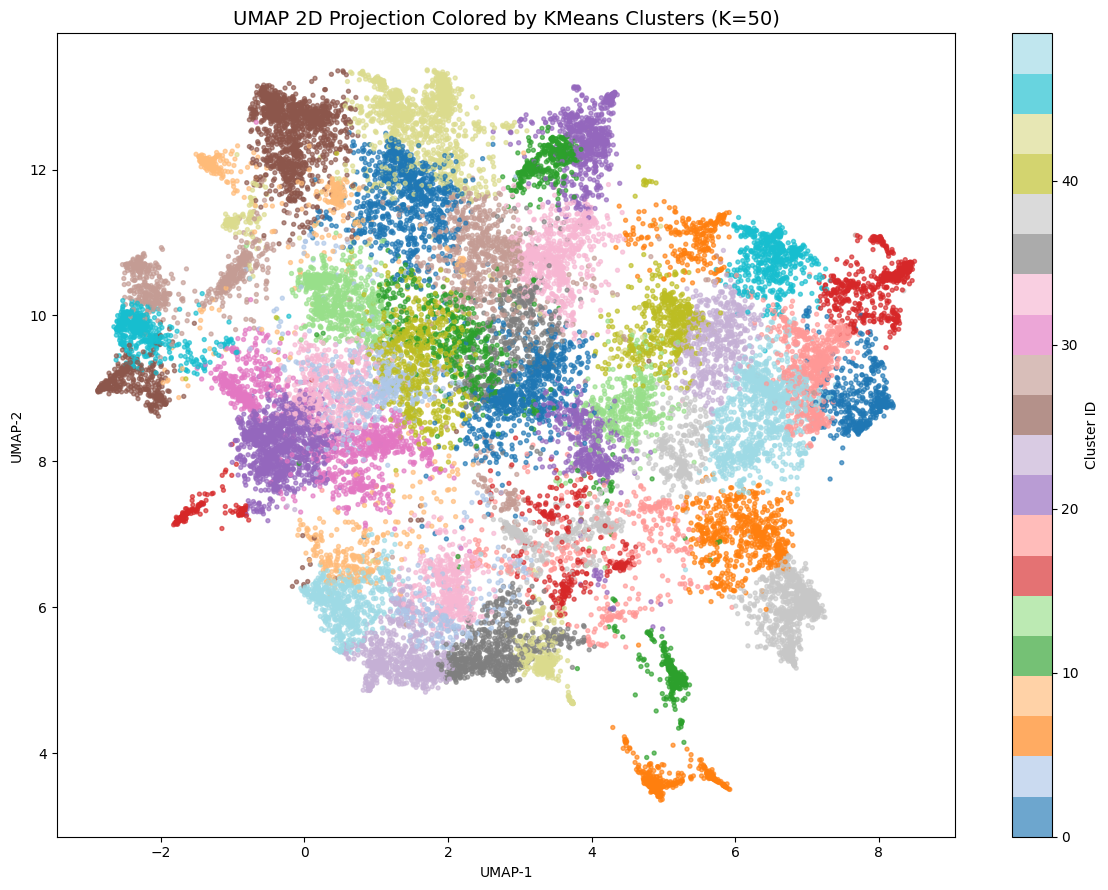

✅ Saved 2D embeddings to: output/embeddings\umap_2d_embeddings_specter.npy
✅ Saved figure to: outputs_manual_topic_model\umap_2d_clusters.png


In [36]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell V2 — Recompute UMAP in 2D and plot clusters
# ══════════════════════════════════════════════════════════════════════════════

umap_2d_model = UMAP(
    n_neighbors=UMAP_N_NEIGHBORS,
    n_components=2,
    min_dist=UMAP_MIN_DIST,
    metric=UMAP_METRIC,
    random_state=SEED,
    low_memory=True
)

xy = umap_2d_model.fit_transform(embeddings)
print("UMAP 2D shape:", xy.shape)

umap2d_path = os.path.join(EMBEDDING_OUTPUT_DIR, f"umap_2d_embeddings_{EMBEDDING_TAG}.npy")
np.save(umap2d_path, xy)

plt.figure(figsize=(12, 9))

scatter = plt.scatter(
    xy[:, 0],
    xy[:, 1],
    c=topics,
    cmap="tab20",
    s=8,
    alpha=0.65
)

plt.title(f"UMAP 2D Projection Colored by KMeans Clusters (K={50})", fontsize=14)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.colorbar(scatter, label="Cluster ID")
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, "umap_2d_clusters.png")
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"✅ Saved 2D embeddings to: {umap2d_path}")
print(f"✅ Saved figure to: {save_path}")

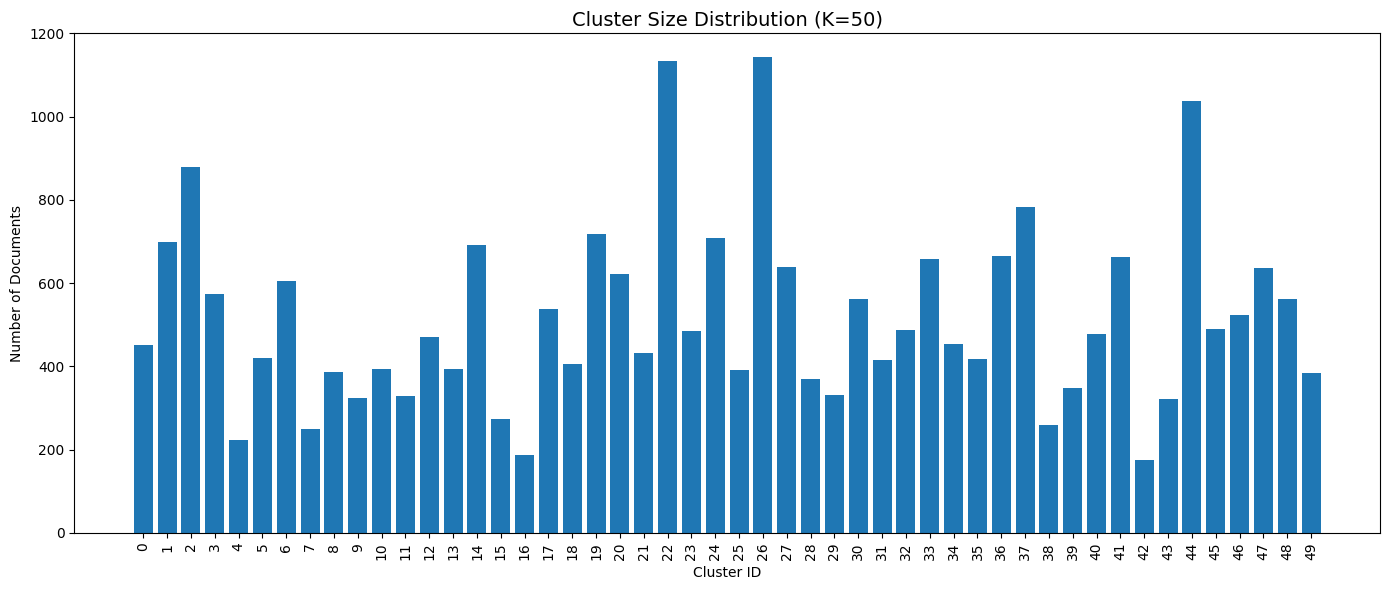

✅ Saved figure to: outputs_manual_topic_model\cluster_size_distribution.png
Top 10 largest clusters:
26    1143
22    1133
44    1038
2      879
37     784
19     717
24     708
1      699
14     692
36     665
Name: count, dtype: int64

Top 10 smallest clusters:
42    175
16    187
4     224
7     250
38    259
15    273
43    321
9     324
11    329
29    331
Name: count, dtype: int64


In [37]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell V4 — Topic size distribution
# ══════════════════════════════════════════════════════════════════════════════

topic_sizes = pd.Series(topics).value_counts().sort_index()

plt.figure(figsize=(14, 6))
plt.bar(topic_sizes.index.astype(str), topic_sizes.values)

plt.title(f"Cluster Size Distribution (K={50})", fontsize=14)
plt.xlabel("Cluster ID")
plt.ylabel("Number of Documents")
plt.xticks(rotation=90)
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, "cluster_size_distribution.png")
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"✅ Saved figure to: {save_path}")

print("Top 10 largest clusters:")
print(topic_sizes.sort_values(ascending=False).head(10))
print("\nTop 10 smallest clusters:")
print(topic_sizes.sort_values(ascending=True).head(10))

## 四、c-tf-idf 主题提取

In [38]:
import pandas as pd
import numpy as np

topic_docs_df = (
    df.groupby("topic")["text"]
    .apply(lambda x: " ".join(x.astype(str)))
    .reset_index()
    .rename(columns={"text": "topic_text"})
)

print(topic_docs_df.head())
print("Number of topics:", len(topic_docs_df))

   topic                                         topic_text
0      0  RADIOECOLOGICAL STUDY OF SOIL-VEGETATION COVER...
1      1  USE OF OCTADECYL AMINE FOR OPTIMIZING THE WATE...
2      2  SAFETY IMPLICATIONS OF DIESEL GENERATOR AGING....
3      3  METHODS OF HEAT LOSS MEASUREMENT FOR A THERMOH...
4      4  PHYSICAL METALLURGY OF MAGNOX FUEL-ELEMENT. On...
Number of topics: 50


### 停用词检查

In [39]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import numpy as np

probe_vectorizer = CountVectorizer(
    stop_words="english",
    min_df=2,
    ngram_range=(1, 1)
)

X_probe = probe_vectorizer.fit_transform(df["text"])
vocab = np.array(probe_vectorizer.get_feature_names_out())

# 文档频率
dfreq = np.asarray((X_probe > 0).sum(axis=0)).ravel()
df_ratio = dfreq / X_probe.shape[0]

freq_df = pd.DataFrame({
    "term": vocab,
    "doc_freq": dfreq,
    "doc_ratio": df_ratio
}).sort_values("doc_ratio", ascending=False)

freq_df.head(50)

,term,doc_freq,doc_ratio
20914,nuclear,25794,1.000000
23300,power,18755,0.727107
25549,results,11732,0.454834
31444,using,10098,0.391486
24687,reactor,9963,0.386253
28524,study,9733,0.377336
22800,plant,9648,0.374040
4474,based,8860,0.343491
31432,used,8632,0.334651
3337,analysis,8062,0.312553


In [40]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

general_stopwords = set(ENGLISH_STOP_WORDS)

academic_stopwords = {
    "study", "studies",
    "paper", "article",
    "result", "results",
    "method", "methods",
    "approach", "approaches",
    "analysis", "research",
    "investigation",
    "based", "using", "use", "used",
    "proposed", "new",
    "effect", "effects",
    "performance",
    "evaluation",
    "model", "models",
    "data", "using"
}

nuclear_background_stopwords = {
    "nuclear",
    "power",
    "energy",
}

noise_stopwords = {
    "et", "al", "fig", "figure", "table",
    "elsevier", "springer", "wiley",
    "copyright"
}

custom_stopwords = (
    general_stopwords
    | academic_stopwords
    | nuclear_background_stopwords
    | noise_stopwords
)

len(custom_stopwords)

356

In [41]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words=list(custom_stopwords),   # 如果是英文语料
    min_df=2,               # 至少在2个topic文档中出现
    ngram_range=(1, 2)      # 可先试 unigram + bigram
)

X_counts = vectorizer.fit_transform(topic_docs_df["topic_text"])
words = np.array(vectorizer.get_feature_names_out())

print("Count matrix shape:", X_counts.shape)

Count matrix shape: (50, 298861)


In [42]:
def compute_c_tf_idf(X_counts):
    """
    X_counts: scipy sparse matrix, shape = (n_topics, vocab_size)
    return:
        c_tf_idf: ndarray, shape = (n_topics, vocab_size)
    """
    # 转成 dense，数据不是特别大时这样最方便
    X = X_counts.astype(float).toarray()

    # 1) class-based TF
    row_sums = X.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    tf = X / row_sums

    # 2) class-based IDF
    # df_x: 出现该词的topic数
    df_words = (X > 0).sum(axis=0)

    # A: 平均topic文档长度
    avg_nr_words = X.sum(axis=1).mean()

    idf = np.log((avg_nr_words / (df_words + 1e-12)) + 1)

    # 3) c-TF-IDF
    c_tf_idf = tf * idf.reshape(1, -1)

    return c_tf_idf

In [43]:
c_tf_idf_matrix = compute_c_tf_idf(X_counts)
print("c-TF-IDF matrix shape:", c_tf_idf_matrix.shape)

c-TF-IDF matrix shape: (50, 298861)


In [44]:
def extract_top_words_per_topic(topic_docs_df, c_tf_idf_matrix, words, top_n=10):
    rows = []

    for row_idx, topic_id in enumerate(topic_docs_df["topic"].tolist()):
        scores = c_tf_idf_matrix[row_idx]
        top_idx = np.argsort(scores)[::-1][:top_n]

        top_words = words[top_idx]
        top_scores = scores[top_idx]

        rows.append({
            "topic": int(topic_id),
            "top_words": list(top_words),
            "top_scores": list(map(float, top_scores)),
            "name": "_".join(top_words[:4]) if len(top_words) > 0 else f"topic_{topic_id}"
        })

    return pd.DataFrame(rows)

In [45]:
topic_info_df = extract_top_words_per_topic(
    topic_docs_df=topic_docs_df,
    c_tf_idf_matrix=c_tf_idf_matrix,
    words=words,
    top_n=10
)

topic_info_df.head(10)

,topic,top_words,top_scores,name
0,0,"[cs, 137, cs 137, soil, radiocesium, plant, fu...","[0.1645158197660843, 0.128532103174828, 0.1215...",cs_137_cs 137_soil
1,1,"[fuel, reactor, neutron, reactors, uranium, co...","[0.1493985262146967, 0.07828718046919737, 0.03...",fuel_reactor_neutron_reactors
2,2,"[safety, risk, plant, assessment, failure, pla...","[0.06551966983795775, 0.05215608052706693, 0.0...",safety_risk_plant_assessment
3,3,"[heat, reactor, safety, water, thermal, core, ...","[0.09154430507665035, 0.09136301925874236, 0.0...",heat_reactor_safety_water
4,4,"[irradiation, reactor, temperature, materials,...","[0.05975880513323403, 0.05031435864316505, 0.0...",irradiation_reactor_temperature_materials
5,5,"[density, nuclei, neutron, functional, mass, d...","[0.07438004602616177, 0.056251670938465975, 0....",density_nuclei_neutron_functional
6,6,"[cs, radioactive, waste, water, adsorption, re...","[0.05409427902472086, 0.048006042399080004, 0....",cs_radioactive_waste_water
7,7,"[radiation, fukushima, health, disaster, plant...","[0.09543343662803697, 0.07357991428080868, 0.0...",radiation_fukushima_health_disaster
8,8,"[control, reactor, optimization, controller, d...","[0.1369435231262076, 0.10801855461313485, 0.07...",control_reactor_optimization_controller
9,9,"[reactor, pressure, stress, fuel, temperature,...","[0.04829335483144732, 0.04684980346420297, 0.0...",reactor_pressure_stress_fuel


In [46]:
topic_name_map = dict(zip(topic_info_df["topic"], topic_info_df["name"]))
df["topic_name"] = df["topic"].map(topic_name_map)

df[["topic", "topic_name", "text"]].head()

,topic,topic_name,text
0,38,reactor_neutron_bnct_radioactive,TRACE-ELEMENT DETERMINATION IN POLYMERS BY NEU...
1,40,dose_plant_dispersion_atmospheric,DIFFUSION IN BUILDING WAKES FOR GROUND-LEVEL R...
2,17,water_plant_species_thermal,OCCURRENCE OF THREATENED AND RARE SPECIES OF H...
3,20,electricity_emissions_renewable_carbon,HAWAII - AN INTERNATIONAL MODEL FOR METHANOL F...
4,19,cs_137_cs 137_fukushima,ACCUMULATION AND KINETICS OF SR-90 IN FISHES A...


In [47]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell H1 — Hierarchical Topic Parameters
# ══════════════════════════════════════════════════════════════════════════════
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import TwoSlopeNorm
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import jensenshannon, pdist
from scipy.sparse import csr_matrix, issparse
from sklearn.linear_model import TheilSenRegressor

# ── Hierarchical topics 集中参数区 ──────────────────────────────────────────────
HIER_USE_CTFIDF = True
HIER_DISTANCE = "cosine"
HIER_LINKAGE_METHOD = "average"   # 可改成 "complete" / "ward"
HIER_LEVEL_TARGETS = [50, 35, 20, 10, 5]
HIER_TOP_WORDS = 8
HIER_LABEL_WORDS = 4
HIER_TOPK_VIS = 30
HIER_COLOR_THRESHOLD = None

# ── 中美技术差距分析集中参数区 ────────────────────────────────────────────────
GAP_START_YEAR = 1990
ROLLING_WINDOW = 3
ROLLING_MIN_PERIODS = None
TREND_MIN_YEARS = 6
TREND_EPS = 1e-4
LEVEL_COMPARISON_TOPK = 10

TIME_DIR = Path(globals().get("TIME_DIR", Path(OUTPUT_DIR) / "time_evolution"))
FIGS_DIR = Path(globals().get("FIGS_DIR", TIME_DIR / "figs"))
HIER_DIR = FIGS_DIR / "hierarchical_topics"
TIME_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)
HIER_DIR.mkdir(parents=True, exist_ok=True)

if ROLLING_MIN_PERIODS is None:
    ROLLING_MIN_PERIODS = ROLLING_WINDOW

hier_params = {
    "use_ctfidf": HIER_USE_CTFIDF,
    "distance": HIER_DISTANCE,
    "linkage_method": HIER_LINKAGE_METHOD,
    "level_targets": HIER_LEVEL_TARGETS,
    "top_words": HIER_TOP_WORDS,
    "label_words": HIER_LABEL_WORDS,
    "topk_vis": HIER_TOPK_VIS,
    "color_threshold": HIER_COLOR_THRESHOLD,
    "gap_start_year": GAP_START_YEAR,
    "rolling_window": ROLLING_WINDOW,
    "rolling_min_periods": ROLLING_MIN_PERIODS,
}

print("✅ Hierarchical topic 参数已初始化")
print(pd.Series(hier_params))


✅ Hierarchical topic 参数已初始化
use_ctfidf                            True
distance                            cosine
linkage_method                     average
level_targets          [50, 35, 20, 10, 5]
top_words                                8
label_words                              4
topk_vis                                30
color_threshold                       None
gap_start_year                        1990
rolling_window                           3
rolling_min_periods                      3
dtype: object


In [48]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell H2 — Hierarchical Topic Helpers
# ══════════════════════════════════════════════════════════════════════════════
def _resolve_required_object(primary_name, fallback_names=None):
    """从 globals() 中解析 notebook 已有对象。"""
    fallback_names = fallback_names or []
    for name in [primary_name] + list(fallback_names):
        if name in globals():
            return globals()[name]
    raise KeyError(f"缺少必要对象: {primary_name}")


def _ensure_dense(matrix):
    """把稀疏矩阵安全转成 dense ndarray。"""
    if issparse(matrix):
        return matrix.toarray()
    return np.asarray(matrix)


def _compute_ctfidf_from_counts(count_matrix):
    """对给定 count matrix 重新计算 c-TF-IDF。"""
    if not issparse(count_matrix):
        count_matrix = csr_matrix(np.asarray(count_matrix, dtype=float))

    if "compute_c_tf_idf" in globals():
        return np.asarray(compute_c_tf_idf(count_matrix))

    X = count_matrix.astype(float).toarray()
    row_sums = X.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    tf = X / row_sums
    df_words = (X > 0).sum(axis=0)
    avg_nr_words = X.sum(axis=1).mean()
    idf = np.log((avg_nr_words / (df_words + 1e-12)) + 1)
    return tf * idf.reshape(1, -1)


def _extract_top_words_from_scores(scores, words_array, top_n=8):
    """从一行 c-TF-IDF 分数中提取 top words。"""
    scores = np.asarray(scores).ravel()
    if scores.size == 0:
        return [], []
    top_idx = np.argsort(scores)[::-1][:top_n]
    top_words = [str(words_array[i]) for i in top_idx]
    top_scores = [float(scores[i]) for i in top_idx]
    return top_words, top_scores


def _format_topic_name(top_words, label_words=4, prefix="topic"):
    """把 top words 格式化成可读主题名。"""
    if len(top_words) == 0:
        return prefix
    return "_".join([str(w) for w in top_words[:label_words]])


def _resolve_level_cluster_counts(n_topics, target_counts, max_levels=5):
    """根据 flat topic 数量自适应生成 L0~L4 的目标簇数。"""
    counts = []
    for c in [n_topics] + list(target_counts):
        c = max(1, min(int(c), int(n_topics)))
        if c not in counts:
            counts.append(c)
    counts = sorted(counts, reverse=True)

    target_n = min(max_levels, int(n_topics))
    while len(counts) < target_n:
        candidates = []
        for hi, lo in zip(counts[:-1], counts[1:]):
            if hi - lo > 1:
                mid = int(round((hi + lo) / 2))
                for cand in [mid, mid + 1, mid - 1]:
                    if lo < cand < hi and cand not in counts:
                        candidates.append((hi - lo, cand))
                        break
        if counts[-1] > 1:
            tail_mid = int(round((counts[-1] + 1) / 2))
            for cand in [tail_mid, tail_mid - 1]:
                if 1 <= cand < counts[-1] and cand not in counts:
                    candidates.append((counts[-1] - 1, cand))
                    break
        if not candidates:
            break
        best = sorted(candidates, key=lambda x: (-x[0], -x[1]))[0][1]
        counts.append(best)
        counts = sorted(set(counts), reverse=True)

    return counts[:target_n]


def build_hierarchical_topic_tree(
    topic_docs_df,
    X_counts,
    c_tf_idf_matrix,
    words,
    base_topic_name_map,
    distance="cosine",
    linkage_method="average",
    top_words=8,
    label_words=4,
):
    """基于 flat topic c-TF-IDF 构建层次树，并为内部节点重算 merged c-TF-IDF。"""
    leaf_topic_ids = topic_docs_df["topic"].astype(int).tolist()
    n_topics = len(leaf_topic_ids)
    if n_topics < 2:
        raise ValueError("flat topic 数量不足，无法构建 hierarchical topics。")

    counts_dense = _ensure_dense(X_counts).astype(float)
    ctfidf_dense = _ensure_dense(c_tf_idf_matrix).astype(float)
    words_array = np.asarray(words)

    if linkage_method == "ward":
        row_norm = np.linalg.norm(ctfidf_dense, axis=1, keepdims=True)
        row_norm[row_norm == 0] = 1.0
        linkage_input = ctfidf_dense / row_norm
        hier_linkage_matrix = linkage(
            linkage_input,
            method="ward",
            optimal_ordering=True,
        )
        linkage_metric_used = "euclidean_on_l2_normalized_c_tf_idf"
    else:
        dist_vec = pdist(ctfidf_dense, metric=distance)
        dist_vec = np.nan_to_num(dist_vec, nan=1.0, posinf=1.0, neginf=0.0)
        hier_linkage_matrix = linkage(
            dist_vec,
            method=linkage_method,
            optimal_ordering=True,
        )
        linkage_metric_used = distance

    node_rows = []
    node_counts = {}
    node_leaf_topics = {}
    active_nodes = list(range(n_topics))
    leafset_to_node_id = {}

    for row_idx, topic_id in enumerate(leaf_topic_ids):
        topic_id = int(topic_id)
        scores = ctfidf_dense[row_idx]
        top_words_i, top_scores_i = _extract_top_words_from_scores(scores, words_array, top_n=top_words)
        name_i = str(base_topic_name_map.get(topic_id, _format_topic_name(top_words_i, label_words, prefix=f"T{topic_id}")))
        short_name_i = _format_topic_name(top_words_i, min(label_words, 3), prefix=f"T{topic_id}")
        node_counts[row_idx] = counts_dense[row_idx].copy()
        node_leaf_topics[row_idx] = [topic_id]
        leafset_to_node_id[(topic_id,)] = row_idx
        node_rows.append({
            "node_id": int(row_idx),
            "left": np.nan,
            "right": np.nan,
            "height": 0.0,
            "n_leaf_topics": 1,
            "leaf_topics": [topic_id],
            "top_words": top_words_i,
            "top_scores": top_scores_i,
            "name": name_i,
            "short_name": short_name_i,
            "is_leaf": True,
        })

    for merge_idx, (left, right, height, size) in enumerate(hier_linkage_matrix):
        left = int(left)
        right = int(right)
        node_id = int(n_topics + merge_idx)
        merged_counts = node_counts[left] + node_counts[right]
        merged_leaf_topics = sorted(set(node_leaf_topics[left]) | set(node_leaf_topics[right]))

        survivors = [nid for nid in active_nodes if nid not in {left, right}]
        active_count_matrix = np.vstack([node_counts[nid] for nid in survivors] + [merged_counts])
        active_ctfidf_matrix = _compute_ctfidf_from_counts(active_count_matrix)
        parent_scores = active_ctfidf_matrix[-1]
        top_words_i, top_scores_i = _extract_top_words_from_scores(parent_scores, words_array, top_n=top_words)
        name_i = _format_topic_name(top_words_i, label_words=label_words, prefix=f"M{node_id}")
        short_name_i = _format_topic_name(top_words_i, label_words=min(label_words, 3), prefix=f"M{node_id}")

        node_counts[node_id] = merged_counts
        node_leaf_topics[node_id] = merged_leaf_topics
        active_nodes = survivors + [node_id]
        leafset_to_node_id[tuple(merged_leaf_topics)] = node_id

        node_rows.append({
            "node_id": node_id,
            "left": left,
            "right": right,
            "height": float(height),
            "n_leaf_topics": int(size),
            "leaf_topics": merged_leaf_topics,
            "top_words": top_words_i,
            "top_scores": top_scores_i,
            "name": name_i,
            "short_name": short_name_i,
            "is_leaf": False,
        })

    hier_node_info_df = pd.DataFrame(node_rows).sort_values("node_id").reset_index(drop=True)

    return {
        "leaf_topic_ids": leaf_topic_ids,
        "counts_dense": counts_dense,
        "ctfidf_dense": ctfidf_dense,
        "words_array": words_array,
        "linkage_matrix": hier_linkage_matrix,
        "node_info_df": hier_node_info_df,
        "leafset_to_node_id": leafset_to_node_id,
        "linkage_metric_used": linkage_metric_used,
    }


def build_hierarchy_level(topic_docs_df, X_counts, words, linkage_matrix, leafset_to_node_id, n_clusters, top_words=8, label_words=4):
    """将 hierarchy 切成指定簇数，并生成该层级的 topic 映射与名称。"""
    leaf_topic_ids = topic_docs_df["topic"].astype(int).tolist()
    topic_to_row = {int(topic_id): idx for idx, topic_id in enumerate(leaf_topic_ids)}
    counts_dense = _ensure_dense(X_counts).astype(float)
    words_array = np.asarray(words)

    raw_cluster_labels = fcluster(linkage_matrix, t=int(n_clusters), criterion="maxclust")
    membership_df = pd.DataFrame({
        "leaf_topic": leaf_topic_ids,
        "cluster_raw": raw_cluster_labels,
    })

    cluster_order = (
        membership_df.groupby("cluster_raw")["leaf_topic"]
        .agg(["size", "min"])
        .sort_values(["size", "min"], ascending=[False, True])
        .reset_index()
    )
    raw_to_cluster = {
        int(row.cluster_raw): int(idx)
        for idx, row in enumerate(cluster_order.itertuples(index=False))
    }
    topic_to_cluster = {
        int(row.leaf_topic): int(raw_to_cluster[int(row.cluster_raw)])
        for row in membership_df.itertuples(index=False)
    }

    cluster_rows = []
    cluster_count_rows = []
    for cluster_id in sorted(set(topic_to_cluster.values())):
        member_topics = sorted([topic for topic, cid in topic_to_cluster.items() if cid == cluster_id])
        row_indices = [topic_to_row[t] for t in member_topics]
        merged_counts = counts_dense[row_indices].sum(axis=0)
        cluster_count_rows.append(merged_counts)
        cluster_rows.append({
            "topic": int(cluster_id),
            "leaf_topics": member_topics,
            "n_leaf_topics": len(member_topics),
            "source_node_id": leafset_to_node_id.get(tuple(member_topics), np.nan),
        })

    cluster_count_matrix = np.vstack(cluster_count_rows)
    cluster_ctfidf_matrix = _compute_ctfidf_from_counts(cluster_count_matrix)

    for row_idx, row in enumerate(cluster_rows):
        top_words_i, top_scores_i = _extract_top_words_from_scores(
            cluster_ctfidf_matrix[row_idx],
            words_array,
            top_n=top_words,
        )
        row["top_words"] = top_words_i
        row["top_scores"] = top_scores_i
        row["name"] = _format_topic_name(top_words_i, label_words=label_words, prefix=f"C{row['topic']}")

    level_topic_info_df = pd.DataFrame(cluster_rows).sort_values("topic").reset_index(drop=True)
    level_topic_name_map = dict(zip(level_topic_info_df["topic"], level_topic_info_df["name"]))

    return topic_to_cluster, level_topic_info_df, level_topic_name_map


def plot_hierarchical_dendrogram(linkage_matrix, leaf_topic_ids, leaf_name_map, node_info_df, out_path, linkage_method, linkage_metric, color_threshold=None, figsize=(24, 10)):
    """绘制 hierarchical dendrogram，并尽量标注内部 merged topic 名称。"""
    leaf_labels = [
        f"T{int(tid)}: {str(leaf_name_map.get(int(tid), f'topic_{int(tid)}'))[:42]}"
        for tid in leaf_topic_ids
    ]

    if color_threshold is None:
        color_threshold = 0.7 * float(np.max(linkage_matrix[:, 2]))

    fig, ax = plt.subplots(figsize=figsize)
    dendro_data = dendrogram(
        linkage_matrix,
        labels=leaf_labels,
        leaf_rotation=90,
        leaf_font_size=9,
        color_threshold=color_threshold,
        above_threshold_color="#8c8c8c",
        ax=ax,
    )

    ax.set_title(
        f"Hierarchical Topic Dendrogram ({linkage_method}, {linkage_metric})",
        fontsize=15,
    )
    ax.set_xlabel("Flat Topics")
    ax.set_ylabel("Linkage Distance")
    ax.grid(True, axis="y", alpha=0.2)

    node_name_lookup = node_info_df.set_index("node_id")["short_name"].to_dict()
    merge_points = []
    n_topics = len(leaf_topic_ids)
    for row_idx, (icoord, dcoord) in enumerate(zip(dendro_data["icoord"], dendro_data["dcoord"])):
        node_id = n_topics + row_idx
        x_pos = 0.5 * (icoord[1] + icoord[2])
        y_pos = dcoord[1]
        merge_points.append((node_id, x_pos, y_pos))

    for node_id, x_pos, y_pos in sorted(merge_points, key=lambda x: x[2], reverse=True)[: min(20, len(merge_points))]:
        label = str(node_name_lookup.get(node_id, f"M{node_id}"))[:40]
        ax.text(
            x_pos,
            y_pos,
            label,
            rotation=90,
            ha="center",
            va="bottom",
            fontsize=7.5,
            color="#4d4d4d",
            alpha=0.9,
        )

    plt.tight_layout()
    plt.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"✅ 已保存层次树图: {out_path}")
    return dendro_data


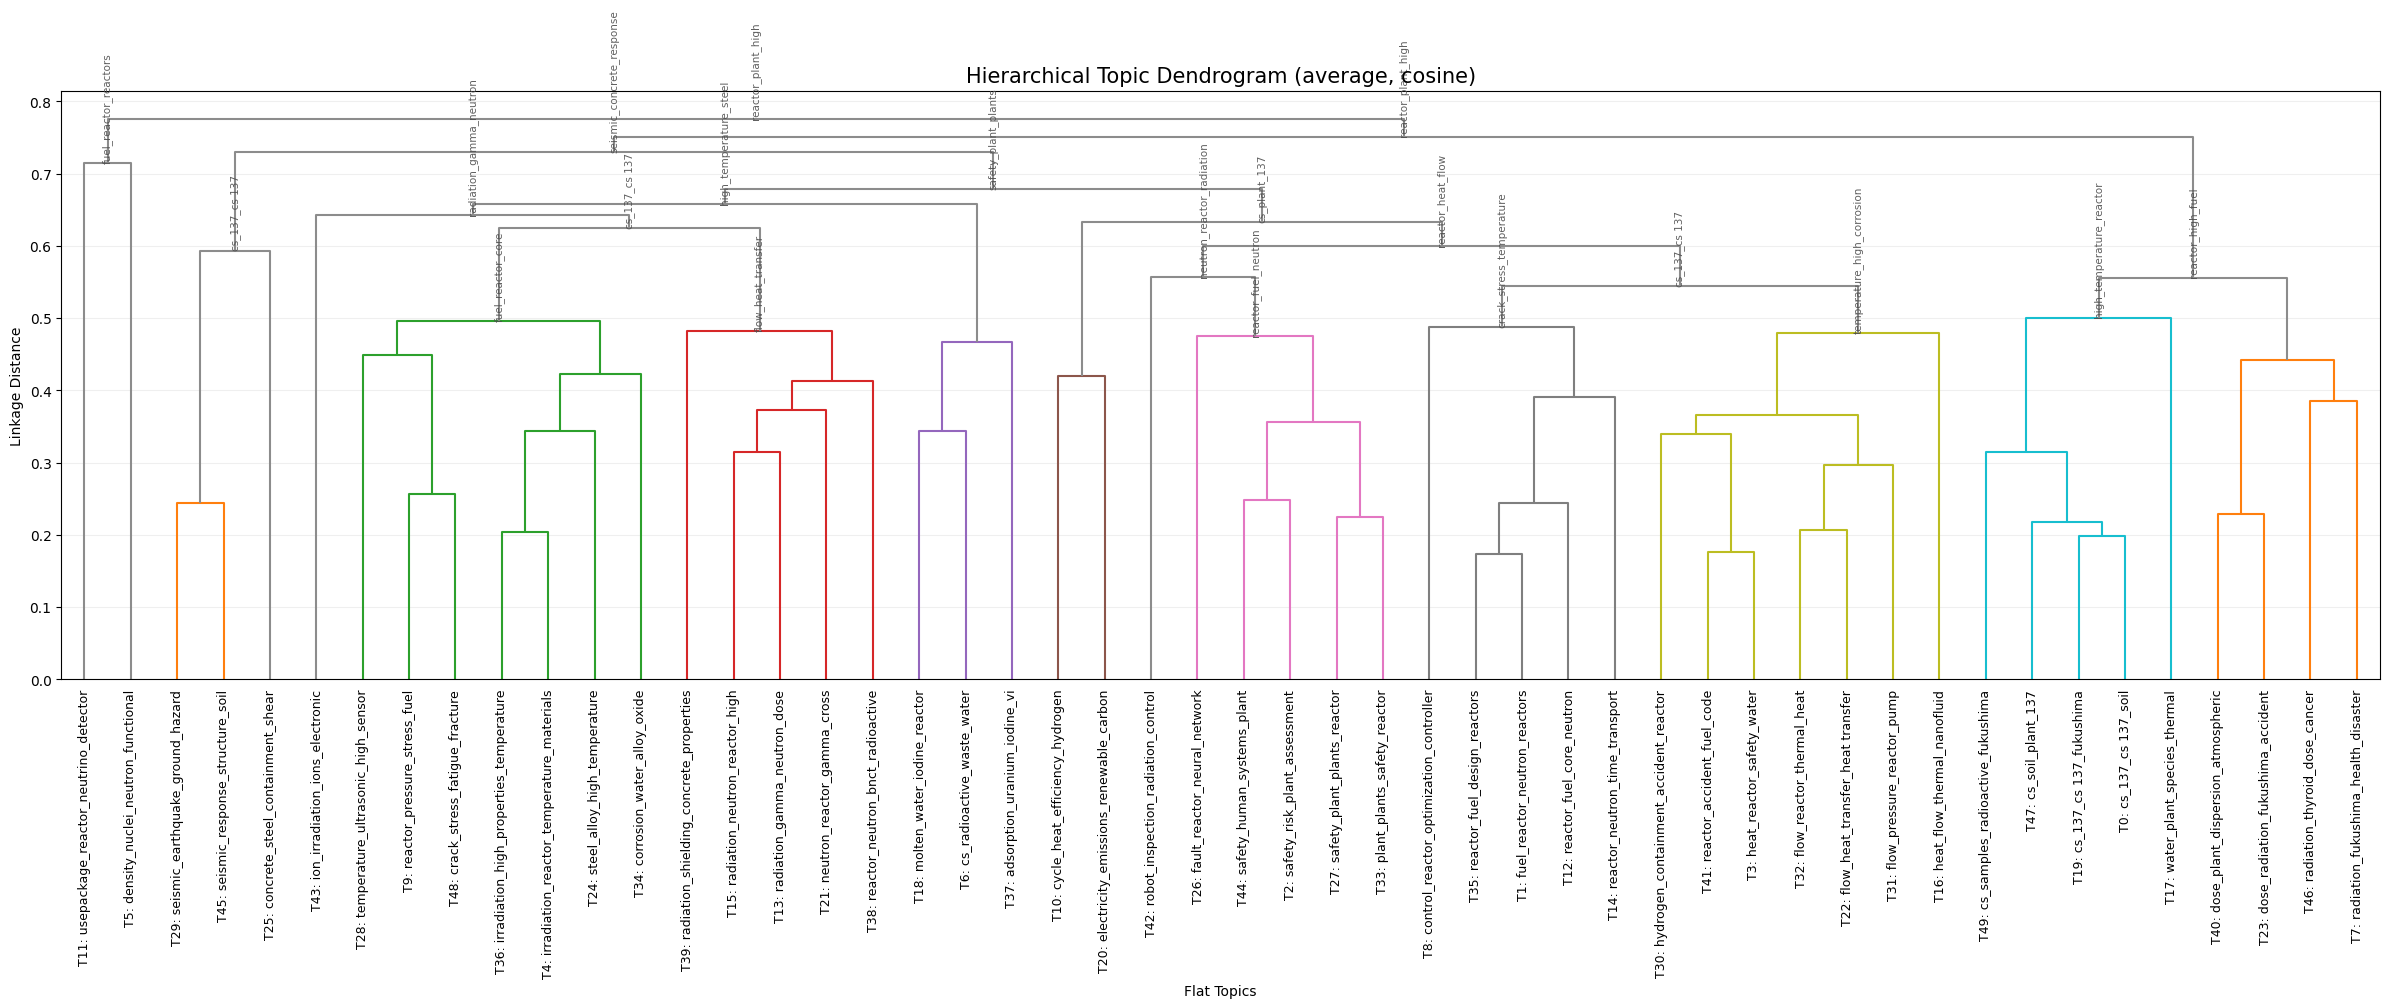

✅ 已保存层次树图: outputs_manual_topic_model\time_evolution\figs\hierarchical_topics\topic_hierarchy_dendrogram_average_cosine.png
✅ hierarchical topics 已构建完成
  level topic_col  n_clusters
0    L0  topic_L0          50
1    L1  topic_L1          35
2    L2  topic_L2          20
3    L3  topic_L3          10
4    L4  topic_L4           5
✅ 节点信息: outputs_manual_topic_model\time_evolution\figs\hierarchical_topics\hier_node_info.csv


In [49]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell H3 — Build Hierarchical Topics / Dendrogram / Level Maps
# ══════════════════════════════════════════════════════════════════════════════
topic_docs_df_ref = _resolve_required_object("topic_docs_df")
X_counts_ref = _resolve_required_object("X_counts")
c_tf_idf_matrix_ref = _resolve_required_object("c_tf_idf_matrix")
words_ref = _resolve_required_object("words")

topic_name_map_base = dict(_resolve_required_object("topic_name_map", fallback_names=["topic_name_map_L0"]))
if len(topic_name_map_base) == 0 and "topic_info_df" in globals():
    topic_name_map_base = dict(zip(topic_info_df["topic"], topic_info_df["name"]))

hierarchy_bundle = build_hierarchical_topic_tree(
    topic_docs_df=topic_docs_df_ref,
    X_counts=X_counts_ref,
    c_tf_idf_matrix=c_tf_idf_matrix_ref,
    words=words_ref,
    base_topic_name_map=topic_name_map_base,
    distance=HIER_DISTANCE,
    linkage_method=HIER_LINKAGE_METHOD,
    top_words=HIER_TOP_WORDS,
    label_words=HIER_LABEL_WORDS,
)

hier_linkage_matrix = hierarchy_bundle["linkage_matrix"]
hier_node_info_df = hierarchy_bundle["node_info_df"]
hier_leaf_topic_ids = hierarchy_bundle["leaf_topic_ids"]
hier_leafset_to_node_id = hierarchy_bundle["leafset_to_node_id"]
hier_linkage_metric_used = hierarchy_bundle["linkage_metric_used"]

hier_level_counts = _resolve_level_cluster_counts(
    n_topics=len(hier_leaf_topic_ids),
    target_counts=HIER_LEVEL_TARGETS,
    max_levels=5,
)

hier_level_maps = {"L0": {int(t): int(t) for t in hier_leaf_topic_ids}}
hier_topic_name_maps = {"L0": dict(topic_name_map_base)}
hier_level_topic_info = {
    "L0": topic_info_df.copy() if "topic_info_df" in globals() else pd.DataFrame({
        "topic": hier_leaf_topic_ids,
        "name": [topic_name_map_base.get(int(t), f"topic_{int(t)}") for t in hier_leaf_topic_ids],
    })
}

if "topic_L0" not in df.columns:
    df["topic_L0"] = df["topic"].astype(int)

globals()["topic_name_map_L0"] = hier_topic_name_maps["L0"]

level_records = [{
    "level": "L0",
    "topic_col": "topic_L0",
    "n_clusters": len(hier_topic_name_maps["L0"]),
}]

for level_idx, n_clusters in enumerate(hier_level_counts[1:], start=1):
    level_name = f"L{level_idx}"
    topic_to_cluster, level_topic_info_df, level_topic_name_map = build_hierarchy_level(
        topic_docs_df=topic_docs_df_ref,
        X_counts=X_counts_ref,
        words=words_ref,
        linkage_matrix=hier_linkage_matrix,
        leafset_to_node_id=hier_leafset_to_node_id,
        n_clusters=n_clusters,
        top_words=HIER_TOP_WORDS,
        label_words=HIER_LABEL_WORDS,
    )

    hier_level_maps[level_name] = topic_to_cluster
    hier_topic_name_maps[level_name] = level_topic_name_map
    hier_level_topic_info[level_name] = level_topic_info_df
    df[f"topic_{level_name}"] = df["topic"].map(topic_to_cluster).astype(int)
    globals()[f"topic_name_map_{level_name}"] = level_topic_name_map

    level_records.append({
        "level": level_name,
        "topic_col": f"topic_{level_name}",
        "n_clusters": int(level_topic_info_df["topic"].nunique()),
    })

hier_level_specs = pd.DataFrame(level_records)

hierarchy_fig_path = HIER_DIR / f"topic_hierarchy_dendrogram_{HIER_LINKAGE_METHOD}_{HIER_DISTANCE}.png"
dendro_data = plot_hierarchical_dendrogram(
    linkage_matrix=hier_linkage_matrix,
    leaf_topic_ids=hier_leaf_topic_ids,
    leaf_name_map=hier_topic_name_maps["L0"],
    node_info_df=hier_node_info_df,
    out_path=hierarchy_fig_path,
    linkage_method=HIER_LINKAGE_METHOD,
    linkage_metric=hier_linkage_metric_used,
    color_threshold=HIER_COLOR_THRESHOLD,
)

hier_node_info_df.to_csv(HIER_DIR / "hier_node_info.csv", index=False)
hier_level_specs.to_csv(HIER_DIR / "hier_level_specs.csv", index=False)
for level_name, info_df in hier_level_topic_info.items():
    info_df.to_csv(HIER_DIR / f"hier_topic_info_{level_name}.csv", index=False)

print("✅ hierarchical topics 已构建完成")
print(hier_level_specs)
print(f"✅ 节点信息: {HIER_DIR / 'hier_node_info.csv'}")


# 中美技术版图可视化

In [50]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell T1 — Generic CN/US Gap Helpers for Multi-Level Topics
# ══════════════════════════════════════════════════════════════════════════════
def prepare_gap_base_df(df_in, topic_cols, year_col="year"):
    """标准化国家列与年份列，并保留后续多层级分析所需字段。"""
    base_df = df_in.copy()

    if "country2" not in base_df.columns:
        if "country_code" in base_df.columns:
            base_df["country2"] = base_df["country_code"].map(
                lambda x: "CN" if str(x).upper() in {"CN", "CHN", "CHINA"} else
                ("US" if str(x).upper() in {"US", "USA", "UNITED STATES"} else "OTHER")
            )
        elif "country" in base_df.columns:
            def _map_country(x):
                s = str(x).upper()
                if ("CHINA" in s) or (s in {"CN", "CHN"}):
                    return "CN"
                if ("UNITED STATES" in s) or (s in {"US", "USA"}):
                    return "US"
                return "OTHER"
            base_df["country2"] = base_df["country"].map(_map_country)
        else:
            raise RuntimeError("没有找到国家列（country / country_code）。")

    base_df["year_int"] = pd.to_numeric(base_df[year_col], errors="coerce")
    required_cols = ["country2", "year_int"] + list(topic_cols)
    base_df = base_df.dropna(subset=required_cols).copy()
    base_df["year_int"] = base_df["year_int"].astype(int)

    for col in topic_cols:
        base_df[col] = pd.to_numeric(base_df[col], errors="coerce")
        base_df = base_df.dropna(subset=[col]).copy()
        base_df[col] = base_df[col].astype(int)

    base_df = base_df[base_df["country2"].isin(["CN", "US"])].copy()
    base_df = base_df[(base_df["year_int"] >= 1900) & (base_df["year_int"] <= 2100)].copy()
    return base_df.reset_index(drop=True)


def topic_label(tid, topic_name_map, max_len=36):
    """统一生成 topic label。"""
    name = str(topic_name_map.get(int(tid), "")).strip()
    if name == "" or name == "nan":
        return f"T{int(tid)}"
    return f"T{int(tid)}: {name[:max_len]}"


def build_topic_time_series(df_in, topic_col="topic", year_col="year_int", country_col="country2"):
    """构建 annual share gap panel。"""
    tmp = df_in[[topic_col, year_col, country_col]].copy()
    tmp = tmp[tmp[country_col].isin(["CN", "US"])].dropna().copy()
    tmp[topic_col] = tmp[topic_col].astype(int)
    tmp[year_col] = tmp[year_col].astype(int)

    counts = (
        tmp.groupby([topic_col, year_col, country_col])
        .size()
        .reset_index(name="n")
    )

    wide = counts.pivot_table(
        index=[topic_col, year_col],
        columns=country_col,
        values="n",
        fill_value=0,
    ).reset_index()

    all_topics = sorted(tmp[topic_col].unique())
    all_years = sorted(tmp[year_col].unique())
    full_idx = pd.MultiIndex.from_product([all_topics, all_years], names=[topic_col, year_col])
    wide = (
        wide.set_index([topic_col, year_col])
        .reindex(full_idx, fill_value=0)
        .reset_index()
        .sort_values([topic_col, year_col])
    )

    for c in ["CN", "US"]:
        if c not in wide.columns:
            wide[c] = 0

    year_totals = (
        tmp.groupby([year_col, country_col])
        .size()
        .unstack(fill_value=0)
        .reindex(all_years, fill_value=0)
    )
    for c in ["CN", "US"]:
        if c not in year_totals.columns:
            year_totals[c] = 0

    wide["share_CN"] = wide["CN"] / wide[year_col].map(year_totals["CN"].to_dict()).replace(0, np.nan)
    wide["share_US"] = wide["US"] / wide[year_col].map(year_totals["US"].to_dict()).replace(0, np.nan)
    wide["share_CN"] = wide["share_CN"].fillna(0.0)
    wide["share_US"] = wide["share_US"].fillna(0.0)

    result = wide[[topic_col, year_col, "CN", "US", "share_CN", "share_US"]].copy()
    result.columns = ["topic", "year", "count_CN", "count_US", "share_CN", "share_US"]
    result["delta"] = result["share_CN"] - result["share_US"]
    result["abs_delta"] = result["delta"].abs()
    return result.sort_values(["topic", "year"]).reset_index(drop=True)


def build_windowed_share_gap(
    df_in,
    topic_col="topic",
    year_col="year_int",
    country_col="country2",
    window_size=3,
    min_periods=None,
):
    """构建 rolling/window share gap panel。"""
    if min_periods is None:
        min_periods = window_size

    tmp = df_in[[topic_col, year_col, country_col]].copy()
    tmp = tmp[tmp[country_col].isin(["CN", "US"])].dropna().copy()
    tmp[topic_col] = tmp[topic_col].astype(int)
    tmp[year_col] = tmp[year_col].astype(int)

    counts = (
        tmp.groupby([topic_col, year_col, country_col])
        .size()
        .reset_index(name="n")
    )

    wide = counts.pivot_table(
        index=[topic_col, year_col],
        columns=country_col,
        values="n",
        fill_value=0,
    ).reset_index()

    for c in ["CN", "US"]:
        if c not in wide.columns:
            wide[c] = 0

    all_topics = sorted(tmp[topic_col].unique())
    all_years = sorted(tmp[year_col].unique())
    full_idx = pd.MultiIndex.from_product([all_topics, all_years], names=[topic_col, year_col])
    wide = (
        wide.set_index([topic_col, year_col])
        .reindex(full_idx, fill_value=0)
        .reset_index()
        .sort_values([topic_col, year_col])
    )

    for c in ["CN", "US"]:
        wide[f"roll_{c}"] = (
            wide.groupby(topic_col)[c]
            .transform(lambda s: s.rolling(window=window_size, min_periods=min_periods).sum())
        )

    wide = wide.dropna(subset=["roll_CN", "roll_US"]).copy()
    for c in ["CN", "US"]:
        year_total = wide.groupby(year_col)[f"roll_{c}"].transform("sum")
        wide[f"share_{c}"] = wide[f"roll_{c}"] / year_total.replace(0, np.nan)

    wide["share_CN"] = wide["share_CN"].fillna(0.0)
    wide["share_US"] = wide["share_US"].fillna(0.0)
    wide["delta"] = wide["share_CN"] - wide["share_US"]
    wide["abs_delta"] = wide["delta"].abs()

    result = wide[[topic_col, year_col, "roll_CN", "roll_US", "share_CN", "share_US", "delta", "abs_delta"]].copy()
    result.columns = ["topic", "year", "window_count_CN", "window_count_US", "share_CN", "share_US", "delta", "abs_delta"]
    return result.sort_values(["topic", "year"]).reset_index(drop=True)


def build_cumulative_gap(panel_df, topic_name_map, start_year=1990):
    """基于 annual/rolling gap panel 构建 cumulative gap panel。"""
    tmp = panel_df[panel_df["year"] >= start_year].copy()
    tmp = tmp.sort_values(["topic", "year"]).reset_index(drop=True)

    all_topics = sorted(tmp["topic"].unique())
    all_years = sorted(tmp["year"].unique())
    full_idx = pd.MultiIndex.from_product([all_topics, all_years], names=["topic", "year"])
    tmp = (
        tmp.set_index(["topic", "year"])
        .reindex(full_idx)
        .reset_index()
        .sort_values(["topic", "year"])
    )

    for col in ["share_CN", "share_US", "delta", "abs_delta"]:
        if col not in tmp.columns:
            tmp[col] = 0.0
    tmp["share_CN"] = tmp["share_CN"].fillna(0.0)
    tmp["share_US"] = tmp["share_US"].fillna(0.0)
    tmp["delta"] = tmp["delta"].fillna(tmp["share_CN"] - tmp["share_US"])
    tmp["abs_delta"] = tmp["delta"].abs()
    tmp["cum_delta"] = tmp.groupby("topic")["delta"].cumsum()
    tmp["cum_abs_delta"] = tmp["cum_delta"].abs()
    tmp["topic_name"] = tmp["topic"].map(topic_name_map)
    return tmp.reset_index(drop=True)


def classify_gap_trends(
    panel_df,
    topic_name_map,
    value_col="delta",
    min_years=6,
    eps=1e-4,
    slope_col=None,
    start_col=None,
    end_col=None,
):
    """对 annual / rolling / cumulative gap 做通用趋势分类。"""
    slope_col = slope_col or f"slope_{value_col}"
    start_col = start_col or f"{value_col}_start"
    end_col = end_col or f"{value_col}_end"

    records = []
    for tid, grp in panel_df.groupby("topic"):
        grp = grp.sort_values("year").dropna(subset=[value_col])
        n_years = len(grp)
        if n_years < min_years:
            records.append({
                "topic": int(tid),
                slope_col: np.nan,
                start_col: np.nan,
                end_col: np.nan,
                "cross_year": np.nan,
                "trend_label": "insufficient",
                "n_years": n_years,
            })
            continue

        years = grp["year"].values.reshape(-1, 1).astype(float)
        vals = grp[value_col].values.astype(float)
        try:
            model = TheilSenRegressor(random_state=SEED, max_subpopulation=5000)
            model.fit(years, vals)
            slope = float(model.coef_[0])
        except Exception:
            slope = float(np.polyfit(years.ravel(), vals, 1)[0])

        start_val = float(vals[0])
        end_val = float(vals[-1])
        cross_year = np.nan
        for i in range(1, len(vals)):
            if ((vals[i - 1] < 0) and (vals[i] >= 0)) or ((vals[i - 1] > 0) and (vals[i] <= 0)):
                cross_year = int(grp["year"].iloc[i])
                break

        if slope > eps and end_val > start_val + eps:
            trend_label = "catching_up"
        elif slope < -eps and end_val < start_val - eps:
            trend_label = "pulling_away"
        else:
            trend_label = "stable"

        records.append({
            "topic": int(tid),
            slope_col: slope,
            start_col: start_val,
            end_col: end_val,
            "cross_year": cross_year,
            "trend_label": trend_label,
            "n_years": n_years,
        })

    out = pd.DataFrame(records)
    out["topic_name"] = out["topic"].map(topic_name_map)
    return out.sort_values("topic").reset_index(drop=True)


def plot_gap_heatmap(panel_df, topic_name_map, value_col="delta", rank_col="abs_delta", topk=30, title="", colorbar_label="", out_path=None, figsize=(18, 10)):
    """绘制 topic × year heatmap。"""
    if panel_df.empty:
        print(f"⚠️ {title} 数据为空，跳过 heatmap")
        return None

    topic_rank = (
        panel_df.groupby("topic")[rank_col]
        .mean()
        .sort_values(ascending=False)
        .head(min(topk, panel_df["topic"].nunique()))
        .index.tolist()
    )
    hm = panel_df[panel_df["topic"].isin(topic_rank)].copy()
    hm["topic_label"] = hm["topic"].map(lambda tid: topic_label(tid, topic_name_map, max_len=28))

    pivot = hm.pivot_table(
        index="topic_label",
        columns="year",
        values=value_col,
        aggfunc="mean",
        fill_value=0,
    )
    label_order = [topic_label(tid, topic_name_map, max_len=28) for tid in topic_rank]
    pivot = pivot.reindex(label_order)

    vmax = float(np.nanmax(np.abs(pivot.values))) if pivot.size else 1.0
    vmax = max(vmax, 1e-8)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(pivot.values, aspect="auto", cmap="RdBu_r", norm=norm)
    ax.set_xticks(np.arange(pivot.shape[1]))
    ax.set_xticklabels(pivot.columns.tolist(), rotation=90)
    ax.set_yticks(np.arange(pivot.shape[0]))
    ax.set_yticklabels(pivot.index.tolist())
    ax.set_xlabel("Year")
    ax.set_ylabel("Topic")
    ax.set_title(title)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(colorbar_label)

    plt.tight_layout()
    if out_path is not None:
        plt.savefig(out_path, dpi=220, bbox_inches="tight")
        print(f"✅ 已保存: {out_path}")
    plt.show()
    plt.close(fig)
    return out_path


def plot_gap_overview(panel_df, topic_name_map, value_col="delta", rank_col="abs_delta", topk=30, title="", ylabel="", out_path=None, figsize=(16, 8)):
    """绘制 top-k 主题的 gap 趋势总览图。"""
    if panel_df.empty:
        print(f"⚠️ {title} 数据为空，跳过 overview")
        return None

    ranked_topics = (
        panel_df.groupby("topic")[rank_col]
        .max()
        .sort_values(ascending=False)
        .head(min(topk, panel_df["topic"].nunique()))
        .index.tolist()
    )

    fig, ax = plt.subplots(figsize=figsize)
    for tid in ranked_topics:
        sub = panel_df[panel_df["topic"] == tid].sort_values("year")
        if sub.empty:
            continue
        ax.plot(
            sub["year"],
            sub[value_col],
            linewidth=1.4,
            alpha=0.85,
            label=topic_label(tid, topic_name_map, max_len=24),
        )

    ax.axhline(0, color="gray", linestyle="--", linewidth=1.1)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, ncol=1)
    plt.tight_layout()
    if out_path is not None:
        plt.savefig(out_path, dpi=220, bbox_inches="tight")
        print(f"✅ 已保存: {out_path}")
    plt.show()
    plt.close(fig)
    return out_path


def plot_gap_bar(panel_df, topic_name_map, year=None, topk=20, title="", out_path=None, figsize=(12, 8)):
    """绘制最新年份或全期平均的 topic gap 条形图。"""
    if panel_df.empty:
        print(f"⚠️ {title} 数据为空，跳过 bar plot")
        return None

    tmp = panel_df.copy()
    if year is not None:
        tmp = tmp[tmp["year"] == year].copy()
        if tmp.empty:
            print(f"⚠️ year={year} 没有数据，跳过 {title}")
            return None
        agg = tmp[["topic", "share_CN", "share_US", "delta", "abs_delta"]].copy()
    else:
        agg = (
            tmp.groupby("topic")[["share_CN", "share_US", "delta", "abs_delta"]]
            .mean()
            .reset_index()
        )

    agg["topic_label"] = agg["topic"].map(lambda tid: topic_label(tid, topic_name_map, max_len=28))
    agg = agg.sort_values("abs_delta", ascending=False).head(min(topk, len(agg)))

    fig, ax = plt.subplots(figsize=figsize)
    colors = ["#E03C31" if x > 0 else "#3C6FE0" for x in agg["delta"]]
    ax.barh(agg["topic_label"], agg["delta"], color=colors, alpha=0.88)
    ax.axvline(0, color="black", linewidth=0.9)
    ax.invert_yaxis()
    ax.set_xlabel("Δ share (CN − US)")
    ax.set_ylabel("Topic")
    ax.set_title(title)
    ax.grid(True, axis="x", alpha=0.25)
    plt.tight_layout()
    if out_path is not None:
        plt.savefig(out_path, dpi=220, bbox_inches="tight")
        print(f"✅ 已保存: {out_path}")
    plt.show()
    plt.close(fig)
    return out_path




def plot_topic_gap_timeseries(
    panel_df,
    topic_name_map,
    tid,
    value_col="delta",
    trend_row=None,
    title_prefix="",
    ylabel="Δ share (CN − US)",
    out_path=None,
    show=False,
    line_color="#7B2CBF",
    fill_alpha=0.16,
):
    """为单个主题绘制时间变化曲线，适合 L1-L4 父主题逐张导出。"""
    sub = panel_df[panel_df["topic"] == tid].sort_values("year").copy()
    if sub.empty:
        return None

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(
        sub["year"],
        sub[value_col],
        "o-",
        color=line_color,
        linewidth=2.6,
        markersize=5.5,
        alpha=0.95,
    )
    ax.fill_between(
        sub["year"],
        sub[value_col],
        0,
        color=line_color,
        alpha=fill_alpha,
    )
    ax.axhline(0, color="gray", linestyle="--", linewidth=1.4, alpha=0.8)

    if trend_row is not None:
        cross_year = trend_row.get("cross_year", np.nan)
        if pd.notna(cross_year):
            ax.axvline(
                cross_year,
                color="green",
                linestyle=":",
                linewidth=2.0,
                alpha=0.9,
                label=f"cross={int(cross_year)}",
            )
            ax.legend(loc="upper right", fontsize=10)

    slope_value = np.nan
    trend_label = ""
    if trend_row is not None:
        trend_label = str(trend_row.get("trend_label", ""))
        slope_candidates = [k for k in trend_row.keys() if str(k).startswith("slope_")]
        if len(slope_candidates) > 0:
            slope_value = trend_row[slope_candidates[0]]

    slope_str = f", slope={slope_value:.2e}" if pd.notna(slope_value) else ""
    title_main = title_prefix if title_prefix else "Topic Gap"
    ax.set_title(f"{title_main} — {trend_label}{slope_str}".strip(" —"), fontsize=18)
    ax.set_xlabel("Year", fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.grid(True, alpha=0.25, linewidth=1.1)

    topic_text = topic_label(tid, topic_name_map, max_len=48)
    ax.text(
        0.01,
        0.98,
        topic_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11,
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.78, "edgecolor": "#dddddd"},
    )

    plt.tight_layout()
    if out_path is not None:
        plt.savefig(out_path, dpi=220, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)
    return out_path


def export_topic_gap_timeseries_batch(
    panel_df,
    trend_summary_df,
    topic_name_map,
    out_dir,
    value_col="delta",
    title_prefix="",
    ylabel="Δ share (CN − US)",
    filename_prefix="topic_gap",
    show=False,
):
    """批量导出每个主题各自的时间变化图，并输出文件索引表。"""
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    trend_dict = (
        trend_summary_df.set_index("topic").to_dict("index")
        if trend_summary_df is not None and not trend_summary_df.empty
        else {}
    )

    topic_ids = sorted(panel_df["topic"].dropna().astype(int).unique().tolist())
    rows = []
    for tid in topic_ids:
        safe_name = str(topic_name_map.get(int(tid), f"topic_{int(tid)}")).replace("/", "_")[:80]
        out_path = out_dir / f"{filename_prefix}_topic_{int(tid)}_{safe_name}.png"
        plot_topic_gap_timeseries(
            panel_df=panel_df,
            topic_name_map=topic_name_map,
            tid=int(tid),
            value_col=value_col,
            trend_row=trend_dict.get(int(tid), {}),
            title_prefix=title_prefix,
            ylabel=ylabel,
            out_path=out_path,
            show=show,
        )
        rows.append({
            "topic": int(tid),
            "topic_name": topic_name_map.get(int(tid), f"topic_{int(tid)}"),
            "file_path": str(out_path),
        })

    file_index_df = pd.DataFrame(rows)
    file_index_path = out_dir / f"{filename_prefix}_file_index.csv"
    file_index_df.to_csv(file_index_path, index=False)
    print(f"✅ 已批量导出 {len(file_index_df)} 张单主题图: {out_dir}")
    return {"file_index": file_index_df, "file_index_path": file_index_path, "out_dir": out_dir}

def export_latest_gap_summary(panel_df, topic_name_map, rank_col="abs_delta", value_cols=None, topn=20):
    """导出某个 panel 的最新年份 top gap summary。"""
    value_cols = value_cols or ["share_CN", "share_US", "delta", rank_col]
    latest_year = int(panel_df["year"].max())
    cols = ["topic", "year"] + value_cols
    out = (
        panel_df[panel_df["year"] == latest_year][cols]
        .copy()
        .assign(topic_name=lambda x: x["topic"].map(topic_name_map))
        .sort_values(rank_col, ascending=False)
        .head(min(topn, panel_df["topic"].nunique()))
    )
    return out.reset_index(drop=True)


def run_gap_suite(
    df_in,
    level_name,
    topic_col,
    topic_name_map,
    start_year=1990,
    rolling_window=3,
    rolling_min_periods=None,
    topk_vis=30,
    trend_min_years=6,
    trend_eps=1e-4,
):
    """对给定层级运行 annual / rolling / cumulative 全套中美差距分析。"""
    rolling_min_periods = rolling_window if rolling_min_periods is None else rolling_min_periods

    level_time_dir = TIME_DIR / f"level_{level_name.lower()}"
    level_fig_dir = FIGS_DIR / f"level_{level_name.lower()}"
    level_time_dir.mkdir(parents=True, exist_ok=True)
    level_fig_dir.mkdir(parents=True, exist_ok=True)

    annual_df = build_topic_time_series(df_in, topic_col=topic_col)
    annual_df = annual_df[annual_df["year"] >= start_year].copy()
    annual_df["topic_name"] = annual_df["topic"].map(topic_name_map)
    annual_trend_summary = classify_gap_trends(
        annual_df,
        topic_name_map=topic_name_map,
        value_col="delta",
        min_years=trend_min_years,
        eps=trend_eps,
        slope_col="slope_delta",
        start_col="delta_start",
        end_col="delta_end",
    )

    rolling_df = build_windowed_share_gap(
        df_in,
        topic_col=topic_col,
        window_size=rolling_window,
        min_periods=rolling_min_periods,
    )
    rolling_df = rolling_df[rolling_df["year"] >= start_year].copy()
    rolling_df["topic_name"] = rolling_df["topic"].map(topic_name_map)
    rolling_trend_summary = classify_gap_trends(
        rolling_df,
        topic_name_map=topic_name_map,
        value_col="delta",
        min_years=trend_min_years,
        eps=trend_eps,
        slope_col="slope_delta",
        start_col="delta_start",
        end_col="delta_end",
    )

    cumulative_df = build_cumulative_gap(
        rolling_df,
        topic_name_map=topic_name_map,
        start_year=start_year,
    )
    cumulative_trend_summary = classify_gap_trends(
        cumulative_df,
        topic_name_map=topic_name_map,
        value_col="cum_delta",
        min_years=trend_min_years,
        eps=trend_eps,
        slope_col="slope_cum_delta",
        start_col="cum_start",
        end_col="cum_end",
    )

    annual_df.to_csv(level_time_dir / "topic_share_yearly.csv", index=False)
    annual_trend_summary.to_csv(level_time_dir / "topic_trend_summary_yearly.csv", index=False)
    rolling_df.to_csv(level_time_dir / f"topic_share_gap_roll{rolling_window}.csv", index=False)
    rolling_trend_summary.to_csv(level_time_dir / f"topic_trend_summary_roll{rolling_window}.csv", index=False)
    cumulative_df.to_csv(level_time_dir / f"topic_cumulative_gap_from_{start_year}.csv", index=False)
    cumulative_trend_summary.to_csv(level_time_dir / f"topic_cumulative_trend_summary_from_{start_year}.csv", index=False)

    annual_latest_summary = export_latest_gap_summary(
        annual_df,
        topic_name_map=topic_name_map,
        rank_col="abs_delta",
        value_cols=["share_CN", "share_US", "delta", "abs_delta"],
        topn=20,
    )
    rolling_latest_summary = export_latest_gap_summary(
        rolling_df,
        topic_name_map=topic_name_map,
        rank_col="abs_delta",
        value_cols=["share_CN", "share_US", "delta", "abs_delta", "window_count_CN", "window_count_US"],
        topn=20,
    )
    cumulative_latest_summary = export_latest_gap_summary(
        cumulative_df,
        topic_name_map=topic_name_map,
        rank_col="cum_abs_delta",
        value_cols=["share_CN", "share_US", "delta", "cum_delta", "cum_abs_delta"],
        topn=20,
    )

    annual_latest_summary.to_csv(level_time_dir / "summary_latest_gap_topics_yearly.csv", index=False)
    rolling_latest_summary.to_csv(level_time_dir / f"summary_latest_gap_topics_roll{rolling_window}.csv", index=False)
    cumulative_latest_summary.to_csv(level_time_dir / f"summary_latest_cumulative_gap_topics_from_{start_year}.csv", index=False)


    if level_name == "L0":
        figure_paths = {
            "annual_heatmap": plot_gap_heatmap(
                annual_df,
                topic_name_map=topic_name_map,
                value_col="delta",
                rank_col="abs_delta",
                topk=topk_vis,
                title=f"{level_name} Topic-Year Share Gap Heatmap (Annual, CN − US)",
                colorbar_label="Δ share = share_CN − share_US",
                out_path=level_fig_dir / "annual_gap_heatmap.png",
            ),
            "annual_bar_latest": plot_gap_bar(
                annual_df,
                topic_name_map=topic_name_map,
                year=int(annual_df["year"].max()) if not annual_df.empty else None,
                topk=min(20, topk_vis),
                title=f"{level_name} Latest Annual Topic Gap",
                out_path=level_fig_dir / "annual_gap_bar_latest.png",
                figsize=(12, max(6, min(20, topk_vis) * 0.38)),
            ),
            "rolling_heatmap": plot_gap_heatmap(
                rolling_df,
                topic_name_map=topic_name_map,
                value_col="delta",
                rank_col="abs_delta",
                topk=topk_vis,
                title=f"{level_name} Topic-Year Share Gap Heatmap (Rolling {rolling_window}Y, CN − US)",
                colorbar_label="Δ share = share_CN − share_US",
                out_path=level_fig_dir / f"rolling_gap_heatmap_roll{rolling_window}.png",
            ),
            "rolling_overview": plot_gap_overview(
                rolling_df,
                topic_name_map=topic_name_map,
                value_col="delta",
                rank_col="abs_delta",
                topk=topk_vis,
                title=f"{level_name} Rolling {rolling_window}Y Gap Overview",
                ylabel="Δ share (CN − US)",
                out_path=level_fig_dir / f"rolling_gap_overview_top_{topk_vis}.png",
            ),
            "cumulative_heatmap": plot_gap_heatmap(
                cumulative_df,
                topic_name_map=topic_name_map,
                value_col="cum_delta",
                rank_col="cum_abs_delta",
                topk=topk_vis,
                title=f"{level_name} Topic-Year Cumulative Gap Heatmap (since {start_year})",
                colorbar_label="Cumulative Δ share",
                out_path=level_fig_dir / f"cumulative_gap_heatmap_from_{start_year}.png",
            ),
            "cumulative_overview": plot_gap_overview(
                cumulative_df,
                topic_name_map=topic_name_map,
                value_col="cum_delta",
                rank_col="cum_abs_delta",
                topk=topk_vis,
                title=f"{level_name} Cumulative Gap Overview (since {start_year})",
                ylabel=f"Cumulative Δ share since {start_year}",
                out_path=level_fig_dir / f"cumulative_gap_overview_top_{topk_vis}.png",
            ),
        }
    else:
        figure_paths = {
            "annual_topic_series": export_topic_gap_timeseries_batch(
                panel_df=annual_df,
                trend_summary_df=annual_trend_summary,
                topic_name_map=topic_name_map,
                out_dir=level_fig_dir / "annual_gap_by_topic",
                value_col="delta",
                title_prefix=f"{level_name} Annual Delta",
                ylabel="Δ share (CN − US)",
                filename_prefix="annual_gap",
                show=False,
            ),
            "rolling_topic_series": export_topic_gap_timeseries_batch(
                panel_df=rolling_df,
                trend_summary_df=rolling_trend_summary,
                topic_name_map=topic_name_map,
                out_dir=level_fig_dir / f"rolling_gap_by_topic_roll{rolling_window}",
                value_col="delta",
                title_prefix=f"{level_name} Rolling {rolling_window}Y Delta",
                ylabel="Δ share (CN − US)",
                filename_prefix=f"rolling_gap_roll{rolling_window}",
                show=False,
            ),
            "cumulative_topic_series": export_topic_gap_timeseries_batch(
                panel_df=cumulative_df,
                trend_summary_df=cumulative_trend_summary,
                topic_name_map=topic_name_map,
                out_dir=level_fig_dir / f"cumulative_gap_by_topic_from_{start_year}",
                value_col="cum_delta",
                title_prefix=f"{level_name} Cumulative Delta",
                ylabel=f"Cumulative Δ share (CN − US)",
                filename_prefix=f"cumulative_gap_from_{start_year}",
                show=False,
            ),
        }


    return {
        "level": level_name,
        "topic_col": topic_col,
        "topic_name_map": topic_name_map,
        "annual": annual_df,
        "annual_trend_summary": annual_trend_summary,
        "rolling": rolling_df,
        "rolling_trend_summary": rolling_trend_summary,
        "cumulative": cumulative_df,
        "cumulative_trend_summary": cumulative_trend_summary,
        "annual_latest_summary": annual_latest_summary,
        "rolling_latest_summary": rolling_latest_summary,
        "cumulative_latest_summary": cumulative_latest_summary,
        "figure_paths": figure_paths,
        "time_dir": level_time_dir,
        "fig_dir": level_fig_dir,
        "n_topics": int(len(topic_name_map)),
    }


✅ 时间演化分析样本数: 9,066
   年份范围: 1990 - 2026
   CN: 5,687 | US: 3,379
   可用层级: ['topic_L0', 'topic_L1', 'topic_L2', 'topic_L3', 'topic_L4']

开始运行 L0 | topic_L0 | 主题数=50
✅ 已保存: outputs_manual_topic_model\time_evolution\figs\level_l0\annual_gap_heatmap.png


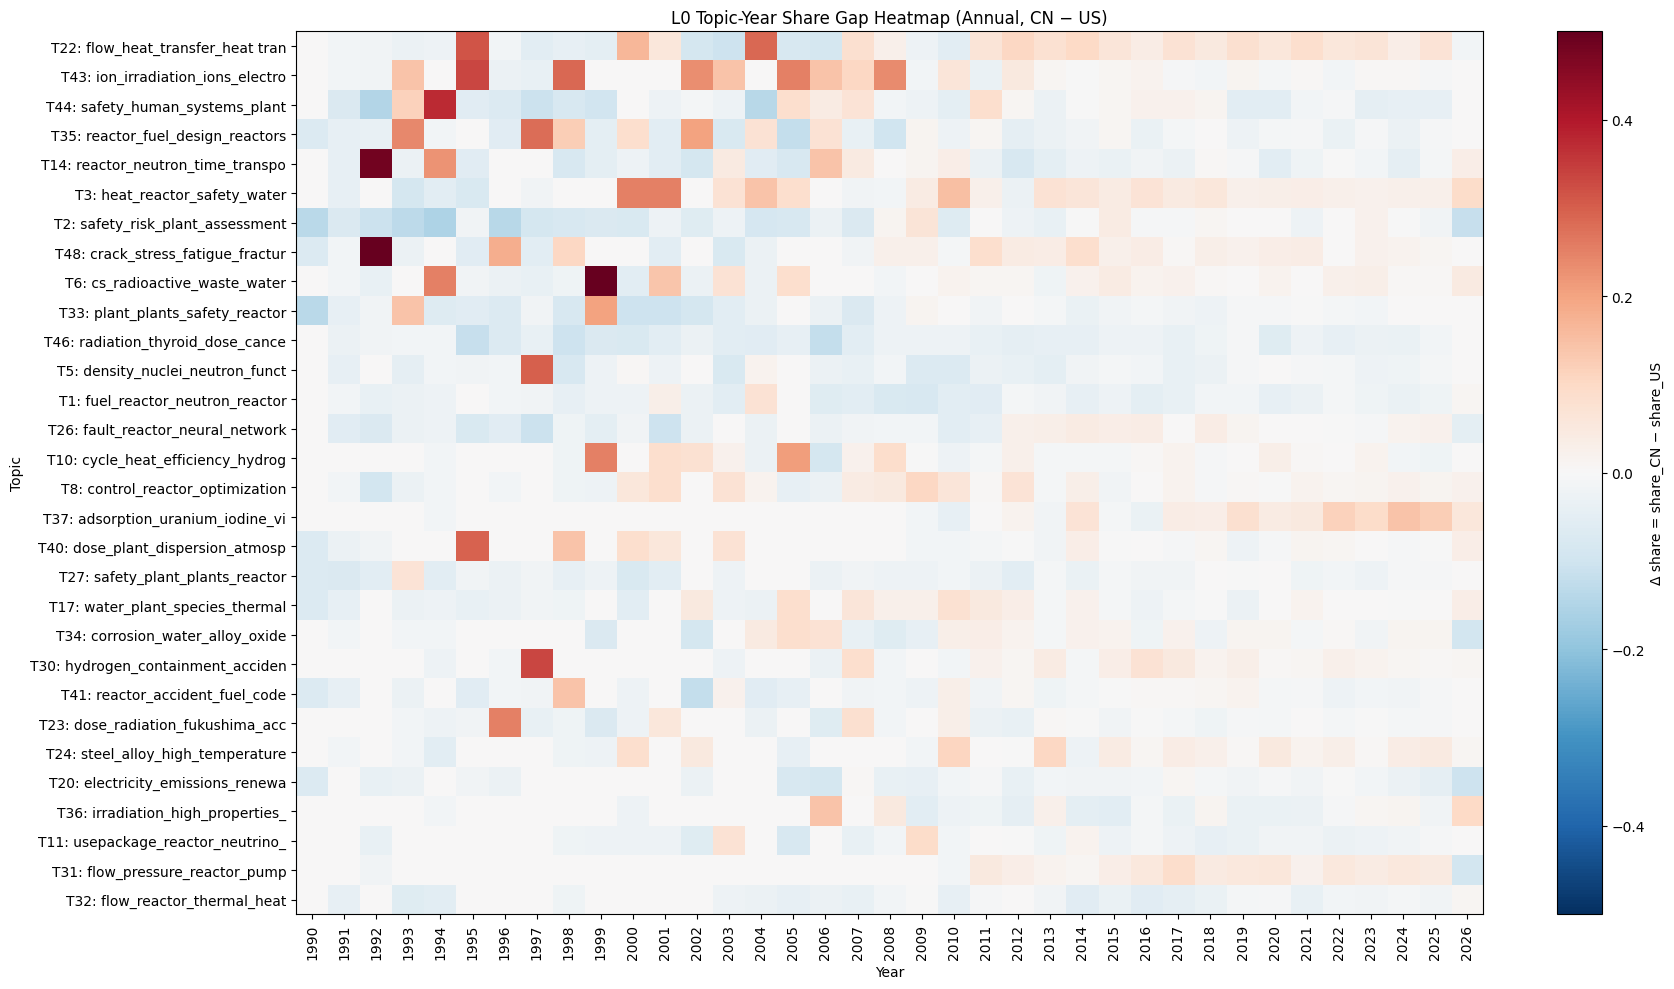

✅ 已保存: outputs_manual_topic_model\time_evolution\figs\level_l0\annual_gap_bar_latest.png


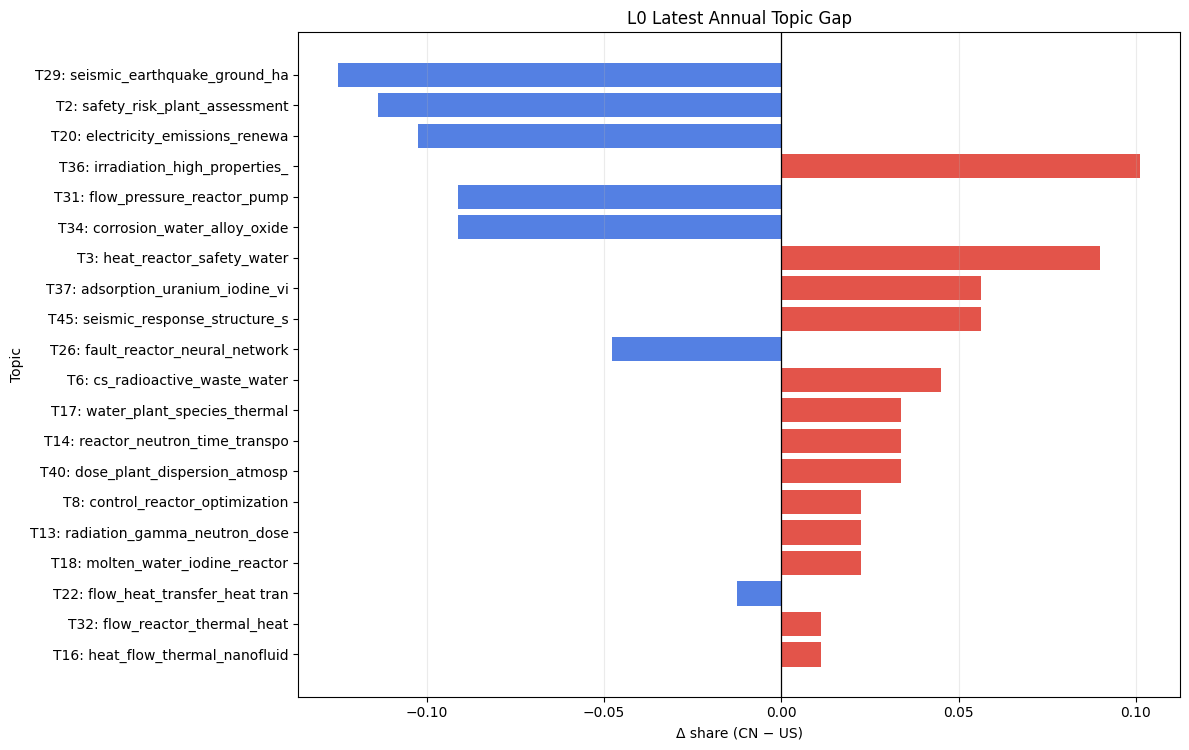

✅ 已保存: outputs_manual_topic_model\time_evolution\figs\level_l0\rolling_gap_heatmap_roll3.png


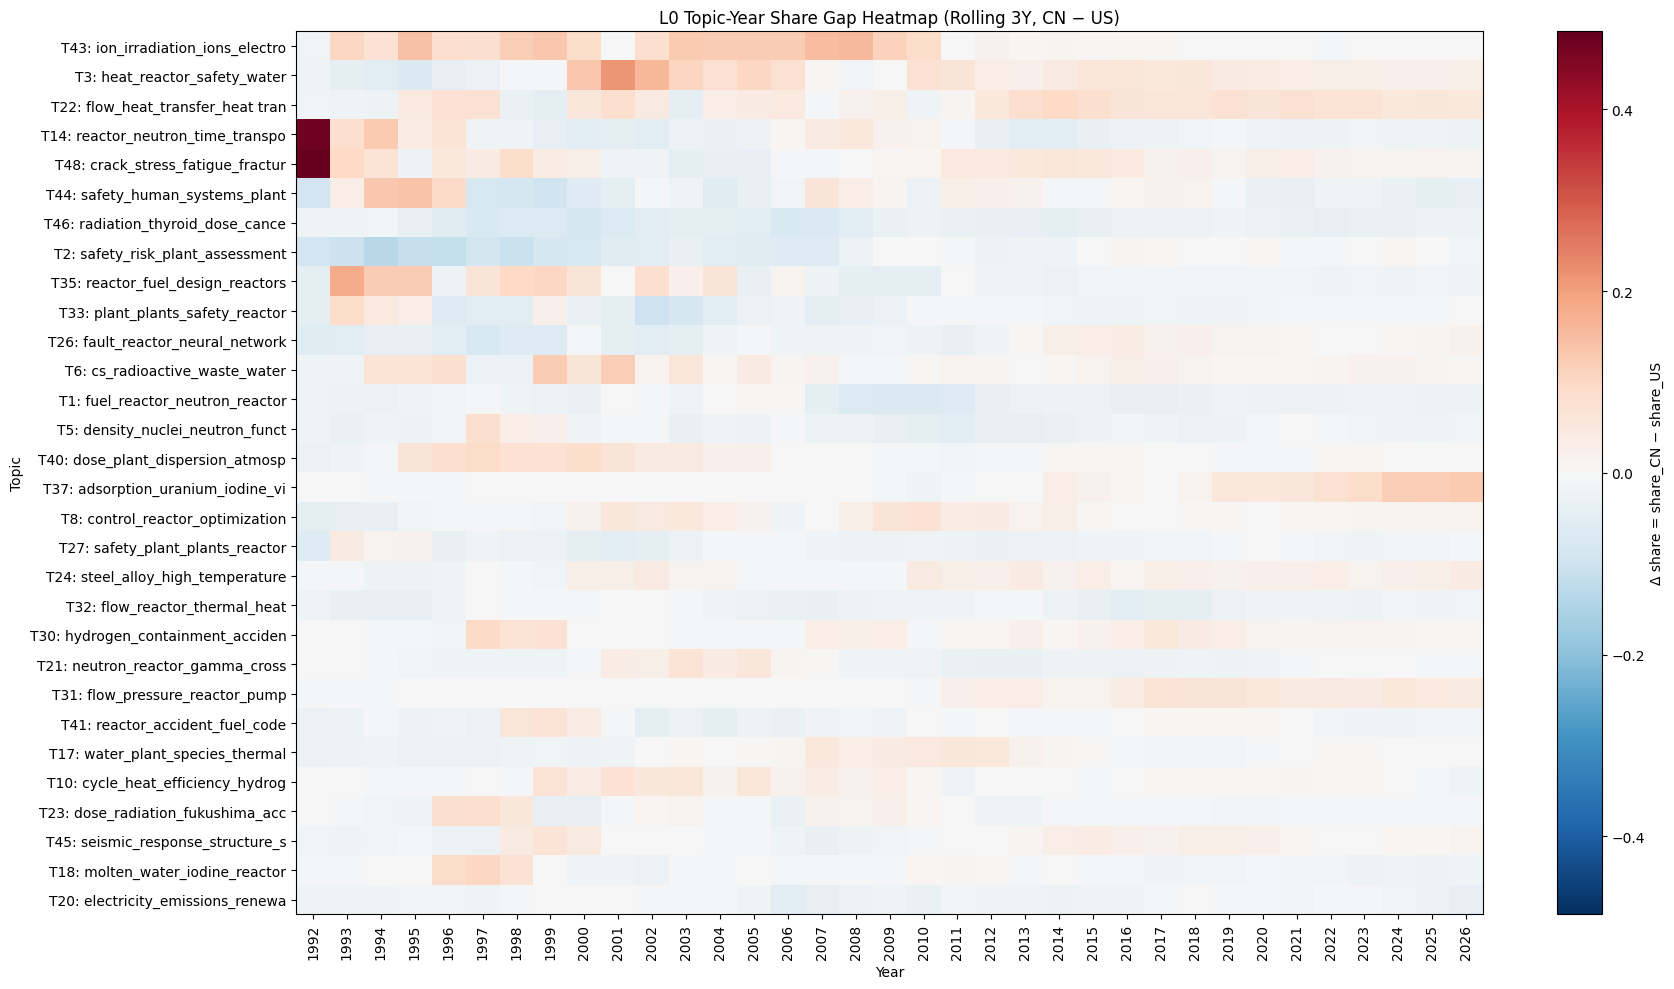

✅ 已保存: outputs_manual_topic_model\time_evolution\figs\level_l0\rolling_gap_overview_top_30.png


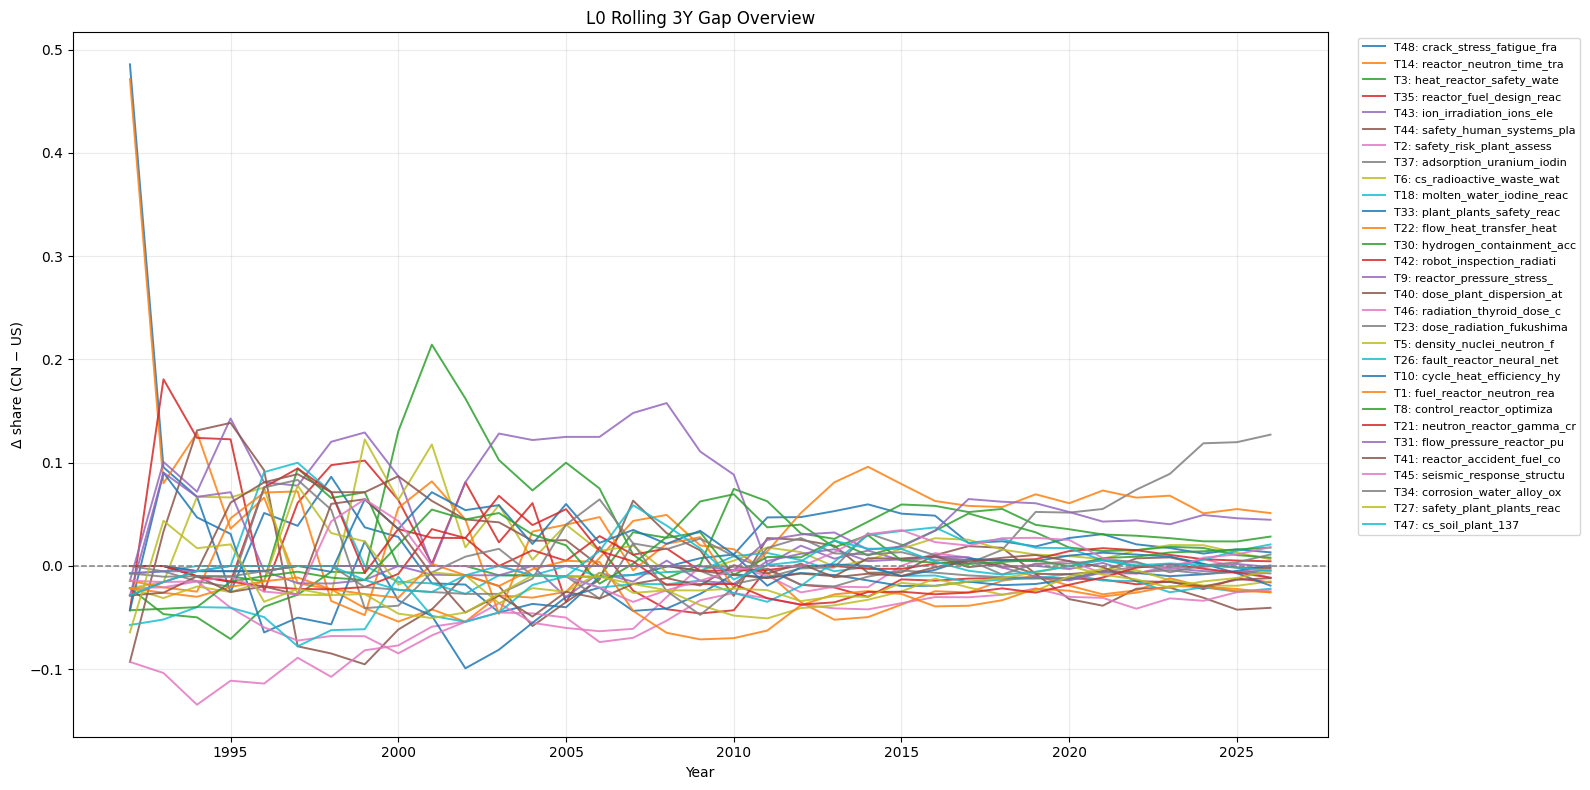

✅ 已保存: outputs_manual_topic_model\time_evolution\figs\level_l0\cumulative_gap_heatmap_from_1990.png


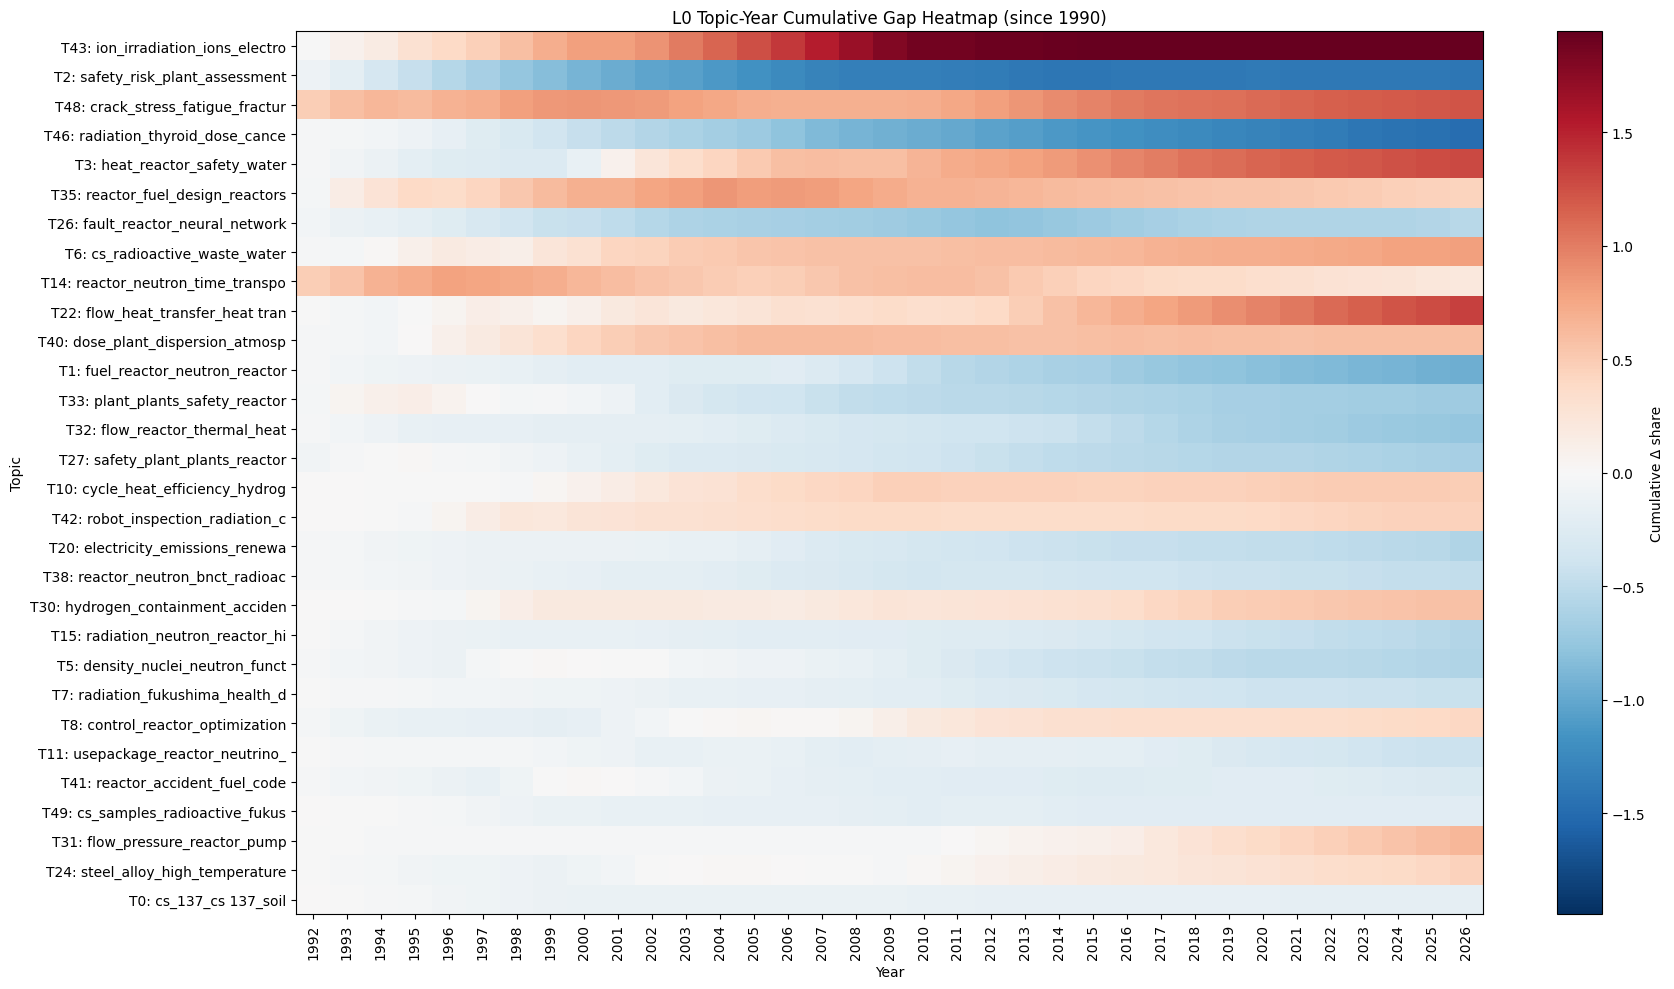

✅ 已保存: outputs_manual_topic_model\time_evolution\figs\level_l0\cumulative_gap_overview_top_30.png


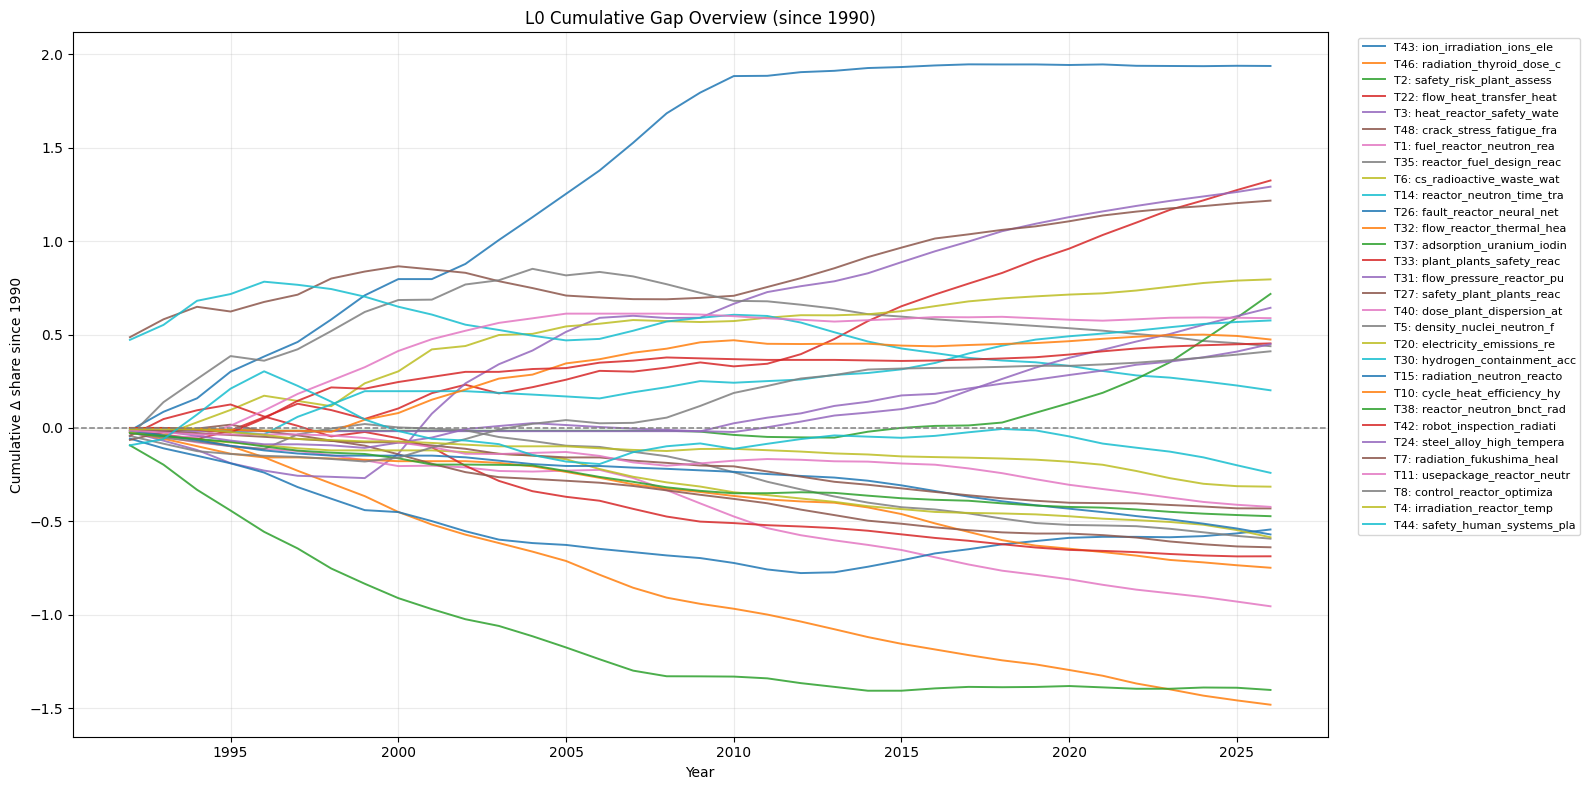


开始运行 L1 | topic_L1 | 主题数=35
✅ 已批量导出 35 张单主题图: outputs_manual_topic_model\time_evolution\figs\level_l1\annual_gap_by_topic
✅ 已批量导出 35 张单主题图: outputs_manual_topic_model\time_evolution\figs\level_l1\rolling_gap_by_topic_roll3
✅ 已批量导出 35 张单主题图: outputs_manual_topic_model\time_evolution\figs\level_l1\cumulative_gap_by_topic_from_1990

开始运行 L2 | topic_L2 | 主题数=20
✅ 已批量导出 20 张单主题图: outputs_manual_topic_model\time_evolution\figs\level_l2\annual_gap_by_topic
✅ 已批量导出 20 张单主题图: outputs_manual_topic_model\time_evolution\figs\level_l2\rolling_gap_by_topic_roll3
✅ 已批量导出 20 张单主题图: outputs_manual_topic_model\time_evolution\figs\level_l2\cumulative_gap_by_topic_from_1990

开始运行 L3 | topic_L3 | 主题数=10
✅ 已批量导出 10 张单主题图: outputs_manual_topic_model\time_evolution\figs\level_l3\annual_gap_by_topic
✅ 已批量导出 10 张单主题图: outputs_manual_topic_model\time_evolution\figs\level_l3\rolling_gap_by_topic_roll3
✅ 已批量导出 10 张单主题图: outputs_manual_topic_model\time_evolution\figs\level_l3\cumulative_gap_by_topic_from_1990

开始运

In [51]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell T2 — Run Annual / Rolling / Cumulative Gap Analysis for L0~L4
# ══════════════════════════════════════════════════════════════════════════════
level_topic_cols = [
    f"topic_L{i}"
    for i in range(5)
    if f"topic_L{i}" in df.columns and f"L{i}" in hier_topic_name_maps
]

te_df = prepare_gap_base_df(df, topic_cols=level_topic_cols, year_col="year")
print(f"✅ 时间演化分析样本数: {len(te_df):,}")
print(f"   年份范围: {te_df['year_int'].min()} - {te_df['year_int'].max()}")
print(f"   CN: {(te_df['country2'] == 'CN').sum():,} | US: {(te_df['country2'] == 'US').sum():,}")
print(f"   可用层级: {level_topic_cols}")

gap_results_by_level = {}
for idx in range(5):
    level_name = f"L{idx}"
    topic_col = f"topic_{level_name}"
    if topic_col not in te_df.columns or level_name not in hier_topic_name_maps:
        continue

    print()
    print("=" * 88)
    print(f"开始运行 {level_name} | {topic_col} | 主题数={len(hier_topic_name_maps[level_name])}")
    print("=" * 88)

    gap_results_by_level[level_name] = run_gap_suite(
        df_in=te_df,
        level_name=level_name,
        topic_col=topic_col,
        topic_name_map=hier_topic_name_maps[level_name],
        start_year=GAP_START_YEAR,
        rolling_window=ROLLING_WINDOW,
        rolling_min_periods=ROLLING_MIN_PERIODS,
        topk_vis=HIER_TOPK_VIS,
        trend_min_years=TREND_MIN_YEARS,
        trend_eps=TREND_EPS,
    )

available_gap_levels = list(gap_results_by_level.keys())
gap_level_inventory = pd.DataFrame({
    "level": available_gap_levels,
    "topic_col": [gap_results_by_level[level]["topic_col"] for level in available_gap_levels],
    "n_topics": [gap_results_by_level[level]["n_topics"] for level in available_gap_levels],
    "time_dir": [str(gap_results_by_level[level]["time_dir"]) for level in available_gap_levels],
    "fig_dir": [str(gap_results_by_level[level]["fig_dir"]) for level in available_gap_levels],
})

gap_level_inventory.to_csv(TIME_DIR / "gap_level_inventory.csv", index=False)
print()
print("✅ 多层级 annual / rolling / cumulative gap 分析已完成")
print(gap_level_inventory)


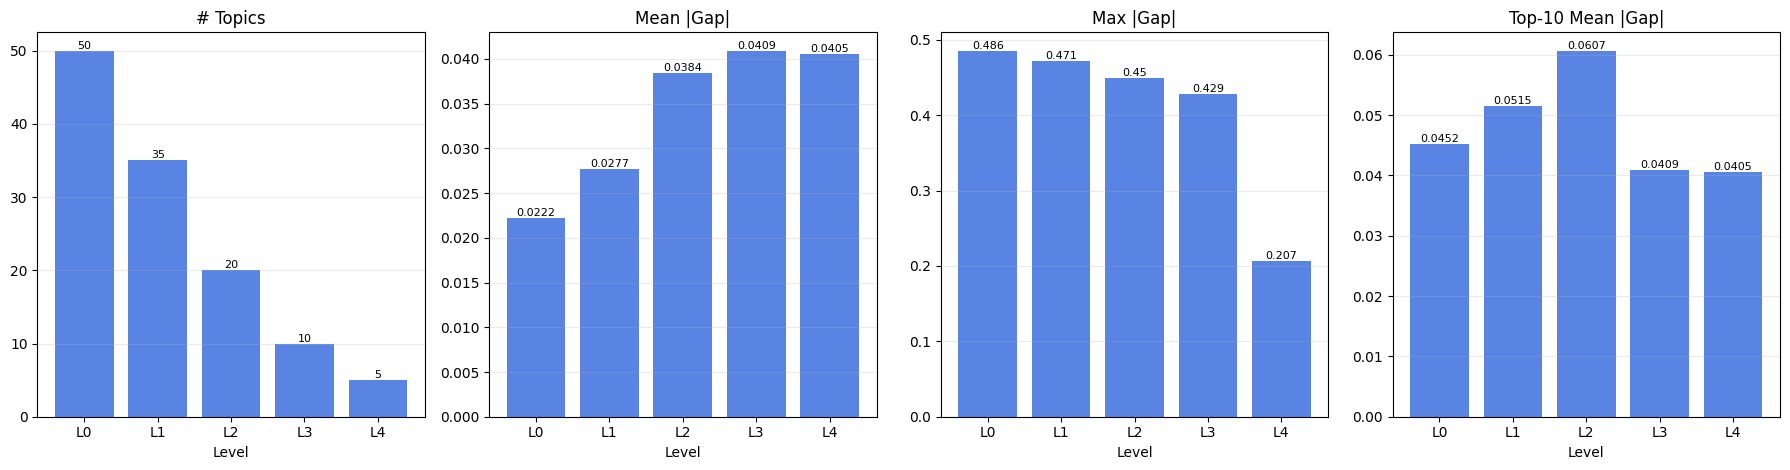

✅ 已保存跨层级比较图: outputs_manual_topic_model\time_evolution\figs\hier_level_gap_comparison.png

✅ 跨层级比较汇总表
  level  n_topics  rolling_mean_abs_gap  rolling_max_abs_gap  \
0    L0        50              0.022221             0.485714   
1    L1        35              0.027694             0.471429   
2    L2        20              0.038415             0.450000   
3    L3        10              0.040929             0.428571   
4    L4         5              0.040498             0.207254   

   rolling_topk_mean_abs_gap  latest_year  latest_mean_abs_gap  \
0                   0.045151         2026             0.016990   
1                   0.051501         2026             0.021504   
2                   0.060682         2026             0.033207   
3                   0.040929         2026             0.039323   
4                   0.040498         2026             0.022005   

   latest_max_abs_gap  cumulative_max_abs_gap  
0            0.127161                1.945618  
1            0.12716

In [52]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell T3 — Cross-Level Gap Comparison Summary
# ══════════════════════════════════════════════════════════════════════════════
def summarize_gap_levels(gap_results_by_level, topk=10):
    """汇总比较不同层级下的中美技术差距强度。"""
    rows = []
    for level_name, result in gap_results_by_level.items():
        rolling_df = result["rolling"].copy()
        cumulative_df = result["cumulative"].copy()
        latest_year = int(rolling_df["year"].max()) if not rolling_df.empty else np.nan
        latest_df = rolling_df[rolling_df["year"] == latest_year].copy() if pd.notna(latest_year) else rolling_df.head(0)

        topic_gap_mean = (
            rolling_df.groupby("topic")["abs_delta"].mean().sort_values(ascending=False)
            if not rolling_df.empty else pd.Series(dtype=float)
        )
        topk_mean_abs_gap = float(topic_gap_mean.head(min(topk, len(topic_gap_mean))).mean()) if len(topic_gap_mean) else np.nan

        rows.append({
            "level": level_name,
            "n_topics": int(result["n_topics"]),
            "rolling_mean_abs_gap": float(rolling_df["abs_delta"].mean()) if not rolling_df.empty else np.nan,
            "rolling_max_abs_gap": float(rolling_df["abs_delta"].max()) if not rolling_df.empty else np.nan,
            "rolling_topk_mean_abs_gap": topk_mean_abs_gap,
            "latest_year": int(latest_year) if pd.notna(latest_year) else np.nan,
            "latest_mean_abs_gap": float(latest_df["abs_delta"].mean()) if not latest_df.empty else np.nan,
            "latest_max_abs_gap": float(latest_df["abs_delta"].max()) if not latest_df.empty else np.nan,
            "cumulative_max_abs_gap": float(cumulative_df["cum_abs_delta"].max()) if not cumulative_df.empty else np.nan,
        })

    out = pd.DataFrame(rows)
    level_order = {f"L{i}": i for i in range(10)}
    out["level_order"] = out["level"].map(level_order)
    out = out.sort_values("level_order").drop(columns="level_order").reset_index(drop=True)
    return out


def plot_level_comparison(level_summary_df, out_path):
    """绘制不同层级技术差距比较图。"""
    metrics = [
        ("n_topics", "# Topics"),
        ("rolling_mean_abs_gap", "Mean |Gap|"),
        ("rolling_max_abs_gap", "Max |Gap|"),
        ("rolling_topk_mean_abs_gap", f"Top-{LEVEL_COMPARISON_TOPK} Mean |Gap|"),
    ]

    fig, axes = plt.subplots(1, len(metrics), figsize=(18, 4.8))
    for ax, (metric, title) in zip(axes, metrics):
        ax.bar(level_summary_df["level"], level_summary_df[metric], color="#3C6FE0", alpha=0.85)
        ax.set_title(title)
        ax.set_xlabel("Level")
        ax.grid(True, axis="y", alpha=0.25)
        for row in level_summary_df.itertuples(index=False):
            value = getattr(row, metric)
            if pd.notna(value):
                label = f"{int(value)}" if metric == "n_topics" else f"{value:.3g}"
                ax.text(row.level, value, label, ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"✅ 已保存跨层级比较图: {out_path}")


level_gap_comparison_df = summarize_gap_levels(
    gap_results_by_level=gap_results_by_level,
    topk=LEVEL_COMPARISON_TOPK,
)
level_gap_comparison_df.to_csv(TIME_DIR / "hier_level_gap_comparison.csv", index=False)

level_comparison_fig_path = FIGS_DIR / "hier_level_gap_comparison.png"
plot_level_comparison(level_gap_comparison_df, out_path=level_comparison_fig_path)

print()
print("✅ 跨层级比较汇总表")
print(level_gap_comparison_df)


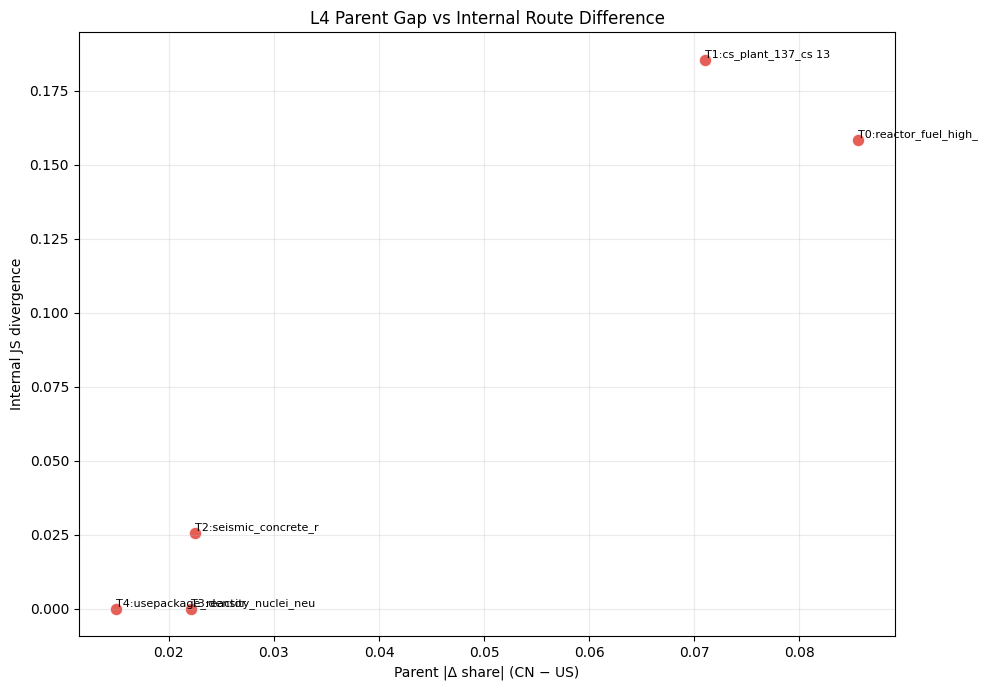

✅ 已保存父主题内部结构差异图: outputs_manual_topic_model\time_evolution\figs\parent_internal_structure_L4.png

✅ 父主题内部结构差异 summary
   parent_topic                           parent_name  n_child_topics  \
0             1                   cs_plant_137_cs 137               9   
1             0               reactor_fuel_high_plant              36   
2             2   seismic_concrete_response_structure               3   
3             3     density_nuclei_neutron_functional               1   
4             4  usepackage_reactor_neutrino_detector               1   

   js_divergence  l1_distance  cosine_distance  top3_child_gap_mean    CN  \
0       0.185545     0.799263         0.350516             0.175345   355   
1       0.158435     0.763045         0.293912             0.071366  4893   
2       0.025749     0.305117         0.046002             0.101706   372   
3       0.000000     0.000000         0.000000             0.000000    36   
4       0.000000     0.000000         0.000000            

In [53]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell T4 — Optional Parent Internal Structure Difference
# ══════════════════════════════════════════════════════════════════════════════
def cosine_distance_safe(p, q):
    """计算两个分布向量的 cosine distance。"""
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    denom = np.linalg.norm(p) * np.linalg.norm(q)
    if denom == 0:
        return 0.0
    return float(1.0 - np.dot(p, q) / denom)


def analyze_parent_internal_structure(
    df_in,
    parent_col,
    child_col,
    parent_name_map,
    start_year=1990,
):
    """比较粗层级父主题内部 flat 子主题在 CN / US 之间的技术路线差异。"""
    tmp = df_in[(df_in["year_int"] >= start_year) & (df_in["country2"].isin(["CN", "US"]))].copy()
    parent_totals = (
        tmp.groupby([parent_col, "country2"])
        .size()
        .unstack(fill_value=0)
        .rename_axis("parent_topic")
        .reset_index()
    )
    for c in ["CN", "US"]:
        if c not in parent_totals.columns:
            parent_totals[c] = 0
    parent_totals["parent_share_CN"] = parent_totals["CN"] / max(parent_totals["CN"].sum(), 1)
    parent_totals["parent_share_US"] = parent_totals["US"] / max(parent_totals["US"].sum(), 1)
    parent_totals["parent_delta"] = parent_totals["parent_share_CN"] - parent_totals["parent_share_US"]
    parent_totals["parent_abs_delta"] = parent_totals["parent_delta"].abs()

    rows = []
    for parent_topic, grp in tmp.groupby(parent_col):
        child_table = grp.groupby(["country2", child_col]).size().unstack(fill_value=0)
        for country in ["CN", "US"]:
            if country not in child_table.index:
                child_table.loc[country] = 0
        child_table = child_table.sort_index(axis=1)

        cn_counts = child_table.loc["CN"].astype(float).values
        us_counts = child_table.loc["US"].astype(float).values
        if cn_counts.sum() == 0 and us_counts.sum() == 0:
            continue

        p = cn_counts / cn_counts.sum() if cn_counts.sum() > 0 else np.zeros_like(cn_counts)
        q = us_counts / us_counts.sum() if us_counts.sum() > 0 else np.zeros_like(us_counts)
        js_div = float(jensenshannon(p + 1e-12, q + 1e-12, base=2.0) ** 2)
        l1_dist = float(np.abs(p - q).sum())
        cos_dist = cosine_distance_safe(p, q)

        child_gap = np.abs(p - q)
        top_child_gap_mean = float(np.sort(child_gap)[::-1][: min(3, len(child_gap))].mean()) if len(child_gap) else np.nan

        rows.append({
            "parent_topic": int(parent_topic),
            "parent_name": parent_name_map.get(int(parent_topic), f"topic_{int(parent_topic)}"),
            "n_child_topics": int((child_table.sum(axis=0) > 0).sum()),
            "js_divergence": js_div,
            "l1_distance": l1_dist,
            "cosine_distance": cos_dist,
            "top3_child_gap_mean": top_child_gap_mean,
        })

    out = pd.DataFrame(rows)
    out = out.merge(parent_totals, how="left", left_on="parent_topic", right_on="parent_topic")
    out = out.sort_values(["js_divergence", "parent_abs_delta"], ascending=[False, False]).reset_index(drop=True)
    return out


def plot_parent_structure_scatter(parent_structure_df, parent_level, out_path):
    """绘制父主题总份额差距 vs 内部结构差异散点图。"""
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(
        parent_structure_df["parent_abs_delta"],
        parent_structure_df["js_divergence"],
        s=80,
        alpha=0.82,
        color="#E03C31",
        edgecolor="white",
        linewidth=0.8,
    )

    to_annotate = parent_structure_df.head(min(12, len(parent_structure_df)))
    for row in to_annotate.itertuples(index=False):
        ax.text(
            row.parent_abs_delta,
            row.js_divergence,
            f"T{row.parent_topic}:{str(row.parent_name)[:18]}",
            fontsize=8,
            ha="left",
            va="bottom",
        )

    ax.set_xlabel("Parent |Δ share| (CN − US)")
    ax.set_ylabel("Internal JS divergence")
    ax.set_title(f"{parent_level} Parent Gap vs Internal Route Difference")
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"✅ 已保存父主题内部结构差异图: {out_path}")


parent_level = next((lvl for lvl in ["L4", "L3", "L2"] if lvl in gap_results_by_level), None)
if parent_level is None:
    print("⚠️ 可用粗层级不足，跳过父主题内部结构差异分析")
else:
    parent_structure_df = analyze_parent_internal_structure(
        df_in=te_df,
        parent_col=f"topic_{parent_level}",
        child_col="topic_L0",
        parent_name_map=hier_topic_name_maps[parent_level],
        start_year=GAP_START_YEAR,
    )
    parent_structure_df.to_csv(TIME_DIR / f"parent_internal_structure_{parent_level}.csv", index=False)

    parent_structure_fig_path = FIGS_DIR / f"parent_internal_structure_{parent_level}.png"
    plot_parent_structure_scatter(
        parent_structure_df=parent_structure_df,
        parent_level=parent_level,
        out_path=parent_structure_fig_path,
    )

    print()
    print("✅ 父主题内部结构差异 summary")
    print(parent_structure_df.head(20))


## 二、技术追赶与技术差距的理论框架

### 2.1 技术追赶理论主线：从“差距”到“路径创造”
技术追赶研究的核心问题是：后发国家如何在既有技术前沿存在的条件下，实现从跟随到并跑乃至领跑。
经典起点是 Abramovitz（1986）提出的“追赶潜力 + 社会能力”框架：技术差距本身提供了学习空间，但是否能转化为增长，取决于制度、教育、组织与产业能力。
Fagerberg（1987）进一步将技术差距引入增长解释，强调创新投入与吸收能力共同决定追赶速度。

随后，研究重心从“是否能追赶”转向“如何追赶”。Lee & Lim（2001）提出三种追赶路径：
1. path-following（路径跟随）
2. path-skipping（路径跨越）
3. path-creating（路径创造）

Park & Lee（2006）和 Lee（2013）指出，技术制度特征（知识累积性、机会窗口、技术周期长短）会显著影响追赶可行性。
Lee（2017）进一步提出 catch-up cycle，强调后发者常借助“技术范式切换、需求结构变化、制度窗口”实现阶段性跨越。

从本研究视角看，这一理论链条意味着：
1. “中美差距”不是静态量，而是沿主题演化的动态轨迹
2. 同一宏观领域内部，不同子主题可能呈现不同追赶机制
3. 层次化主题结构有助于区分“总量差距缩小”与“结构性分化扩大”

### 2.2 技术差距轨道测度的实证进展

#### 2.2.1 从总量差距到轨道差距
早期实证多以 R&D、TFP、专利总量衡量差距，优势是可比性强，但难以揭示“在哪些技术轨道上追赶”。
近年来研究逐步转向主题级、网络级和时序级测度，强调技术竞争的结构维度。

#### 2.2.2 典型测度方法
围绕“轨道（trajectory）”的实证通常采用以下方法：
1. 份额差距法：比较国家在主题 i 上的年度份额差 $\Delta_{i,t}=s_{CN,i,t}-s_{US,i,t}$
2. 滚动窗口差距：用 3-5 年滚动份额平滑短期噪声，识别中期趋势
3. 累积差距：对年度差距累加，刻画长期路径依赖与结构性领先/落后
4. 路径交叉点：识别 $\Delta_{i,t}$ 从负到正（或反向）年份，判定“追赶拐点”
5. 结构差异测度：使用 Jensen-Shannon divergence、L1 distance、cosine distance 比较父主题内部子主题分布差异

#### 2.2.3 与本 notebook 一致的可复现实证框架
本研究当前 notebook 的测度流程可概括为：
1. 文本嵌入与主题识别：BERT 嵌入 + UMAP + KMeans + c-TF-IDF 主题命名
2. 层次主题构建：由 L0 到 L4 逐层聚合，形成“技术版图树”
3. 差距轨道计算：annual / rolling / cumulative 三套面板
4. 趋势识别：Theil-Sen 斜率 + cross-year 判定 catching_up / pulling_away / stable
5. 跨层级比较：比较不同层级的平均 |gap|、最大 |gap| 与 top-k 强差距主题

该框架的优势在于：既保留宏观可解释性，又能识别中观结构差异，适合回答“哪些方向在追赶、哪些方向在分化、分化发生在何层级”这类问题。

### 2.3 建议优先检索与引用的代表性文献（可直接扩展）
1. Abramovitz, M. (1986). Catching Up, Forging Ahead, and Falling Behind. Journal of Economic History.
2. Fagerberg, J. (1987). A technology gap approach to why growth rates differ. Research Policy.
3. Lee, K., & Lim, C. (2001). Technological regimes, catching-up and leapfrogging. Research Policy.
4. Park, K.-H., & Lee, K. (2006). Linking the technological regime to the technological catch-up. Industrial and Corporate Change.
5. Lee, K. (2013). Schumpeterian Analysis of Economic Catch-up. Cambridge University Press.
6. Lee, K. (2017). Catch-up cycles and changes in industrial leadership. Research Policy.
7. Kwon, S., Lee, J., & Lee, S. (2017). International Trends in Technological Progress: Evidence from Patent Citations. The Economic Journal.
8. Souzanchi Kashani, E., Radosevic, S., et al. (2022). The intellectual evolution of the technological catch-up literature. Research Policy.
9. Huang, Z., et al. (2024). Dynamic structure-coupling and lead-lag distance between science and technology. Technological Forecasting and Social Change.

### 2.4 可直接写入论文的方法说明（简版）
“本文将技术差距定义为中美在同一主题上的相对研究份额差，并将其置于多层级主题树中进行动态追踪。具体地，先基于预训练语言模型生成文献向量，经 UMAP 降维与 KMeans 聚类识别基础主题（L0），再通过层次聚类构建上位主题（L1-L4）。在每个层级上，分别计算年度差距、滚动窗口差距与累积差距，并通过 Theil-Sen 斜率识别追赶趋势。该方法可同时刻画技术追赶的速度、方向与结构性位置，从而将‘是否追赶’扩展为‘在何轨道上追赶’。”